In [2]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize']= (12,6)

In [3]:
# Load optimized data from pickle file (data types preserved)
import pickle

with open('../../data/train_optimized.pkl', 'rb') as f:
    df = pickle.load(f)

print("="*80)
print(f"Dataset shape: {df.shape}")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

Dataset shape: (590540, 434)
Memory usage: 882.61 MB
Memory usage: 882.61 MB


Data

In this competition you are predicting the probability that an online transaction is fraudulent, as denoted by the binary target isFraud.

The data is broken into two files identity and transaction, which are joined by TransactionID.

Categorical Features

ProductCD
emaildomain
card1 - card6
addr1, addr2
P_emaildomain
R_emaildomain
M1 - M9
DeviceType
DeviceInfo
id_12 - id_38

The TransactionDT feature is a timedelta from a given reference datetime (not an actual timestamp).

In [4]:
## 1. Target Distribution (Fraud Rate Analysis)

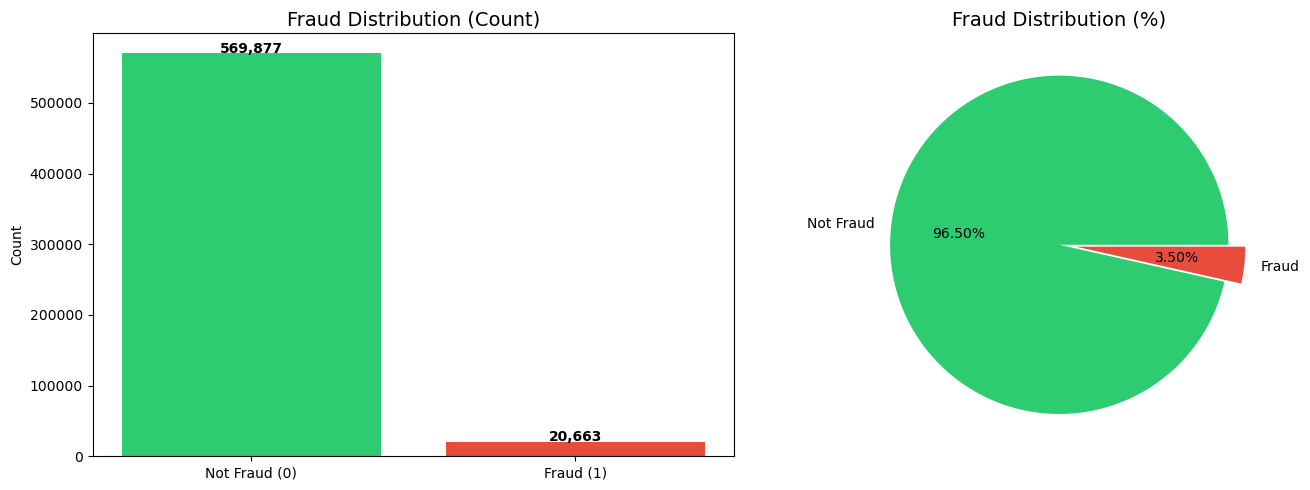

Fraud Rate: 3.50%
Class Imbalance Ratio: 1:27


In [5]:
# Target distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
fraud_counts = df['isFraud'].value_counts()
axes[0].bar(['Not Fraud (0)', 'Fraud (1)'], fraud_counts.values, color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Fraud Distribution (Count)', fontsize=14)
axes[0].set_ylabel('Count')
for i, v in enumerate(fraud_counts.values):
    axes[0].text(i, v + 1000, f'{v:,}', ha='center', fontweight='bold')

# Percentage pie chart
axes[1].pie(fraud_counts.values, labels=['Not Fraud', 'Fraud'], autopct='%1.2f%%', 
            colors=['#2ecc71', '#e74c3c'], explode=[0, 0.1])
axes[1].set_title('Fraud Distribution (%)', fontsize=14)

plt.tight_layout()
plt.show()

print(f"Fraud Rate: {df['isFraud'].mean()*100:.2f}%")
print(f"Class Imbalance Ratio: 1:{int((1-df['isFraud'].mean())/df['isFraud'].mean())}")

In [6]:
## 2. Feature Groups Overview (IEEE Dataset Structure)

IEEE FRAUD DETECTION - FEATURE GROUPS
Transaction Core         :   4 columns
Card Info                :   6 columns
Address                  :   2 columns
Email Domain             :   2 columns
M Features (Match)       :   9 columns
C Features (Count)       :  14 columns
D Features (Timedelta)   :  15 columns
V Features (Vesta)       : 339 columns
ID Features              :  38 columns
Device Info              :   2 columns
TOTAL                    : 431 columns


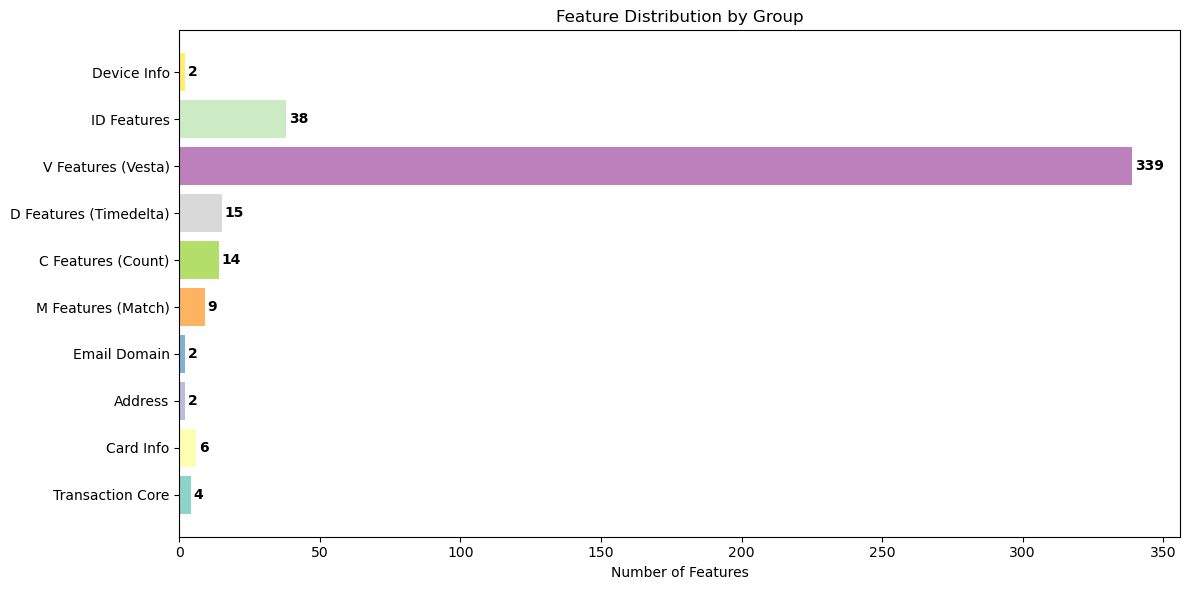

In [7]:
# Group columns by their prefix/category
feature_groups = {
    'Transaction Core': ['TransactionDT', 'TransactionAmt', 'ProductCD', 'isFraud'],
    'Card Info': [col for col in df.columns if col.startswith('card')],
    'Address': [col for col in df.columns if col.startswith('addr')],
    'Email Domain': [col for col in df.columns if 'emaildomain' in col.lower()],
    'M Features (Match)': [col for col in df.columns if col.startswith('M')],
    'C Features (Count)': [col for col in df.columns if col.startswith('C') and col[1:].isdigit()],
    'D Features (Timedelta)': [col for col in df.columns if col.startswith('D') and col[1:].isdigit()],
    'V Features (Vesta)': [col for col in df.columns if col.startswith('V')],
    'ID Features': [col for col in df.columns if col.startswith('id_')],
    'Device Info': [col for col in df.columns if 'device' in col.lower()],
}

print("="*80)
print("IEEE FRAUD DETECTION - FEATURE GROUPS")
print("="*80)

total = 0
group_sizes = {}
for group, cols in feature_groups.items():
    existing_cols = [c for c in cols if c in df.columns]
    group_sizes[group] = len(existing_cols)
    total += len(existing_cols)
    print(f"{group:25s}: {len(existing_cols):3d} columns")

print("="*80)
print(f"{'TOTAL':25s}: {total:3d} columns")

# Visualize group sizes
plt.figure(figsize=(12, 6))
groups = list(group_sizes.keys())
sizes = list(group_sizes.values())
colors = plt.cm.Set3(np.linspace(0, 1, len(groups)))

bars = plt.barh(groups, sizes, color=colors)
plt.xlabel('Number of Features')
plt.title('Feature Distribution by Group')

for bar, size in zip(bars, sizes):
    plt.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2, 
             f'{size}', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [8]:
# List categorical columns (object and category types)
categorical_cols = [col for col in df.columns if df[col].dtype in ['object', 'category']]

# High cardinality categorical columns (>25 unique values)
categorical_but_high_cardinality = [col for col in categorical_cols 
                                    if df[col].nunique() > 25]

# Low cardinality categorical columns (<=25 unique values) - SEPARATED
categorical_cols_clean = [col for col in categorical_cols 
                          if col not in categorical_but_high_cardinality]

# All numeric columns
numeric_cols = [col for col in df.columns 
                if df[col].dtype in ['int64', 'float64', 'Int32', 'Int8', 'Int16']]

# Numeric columns that behave like categorical (<25 unique values)
numeric_but_categorical = [col for col in numeric_cols 
                          if df[col].nunique() < 25 
                          and col not in ['isFraud', 'TransactionID']]

# Pure numeric columns (continuous) - SEPARATED
numeric_cols_clean = [col for col in numeric_cols 
                      if col not in numeric_but_categorical 
                      and col not in ['isFraud', 'TransactionID']]

# Continuous numeric columns - V features vs Non-V features
numeric_cols_v = [col for col in numeric_cols_clean if col.startswith('V')]
numeric_cols_non_v = [col for col in numeric_cols_clean if not col.startswith('V')]

print("="*80)
print("COLUMN CLASSIFICATION")
print("="*80)

print(f"\n📌 CATEGORICAL COLUMNS: {len(categorical_cols)}")
print(f"   - Low Cardinality (<=50 unique): {len(categorical_cols_clean)}")
print(f"   - High Cardinality (>50 unique): {len(categorical_but_high_cardinality)}")

print(f"\n📌 NUMERIC COLUMNS: {len(numeric_cols)}")
print(f"   - Continuous (>=20 unique): {len(numeric_cols_clean)}")
print(f"       • V Features: {len(numeric_cols_v)}")
print(f"       • Non-V Features: {len(numeric_cols_non_v)}")
print(f"   - Categorical-like (<20 unique): {len(numeric_but_categorical)}")

print(f"\n📌 TARGET & ID: 2 (isFraud, TransactionID)")

# Consistency check
total_shown = len(categorical_cols) + len(numeric_cols) + 2  # +2 for isFraud and TransactionID
print(f"\n📌 TOTAL: {len(df.columns)} columns")
print(f"   ✓ Check: {len(categorical_cols)} (cat) + {len(numeric_cols)} (num) + 2 (target/id) = {total_shown}")
print("="*80)

# Display the column lists
print(f"\n📌 CONTINUOUS NUMERIC (Non-V Features): {len(numeric_cols_non_v)}")
print(f"   {numeric_cols_non_v}")
print(f"\nCategorical (Low Cardinality): {categorical_cols_clean}")
print(f"\nCategorical (High Cardinality): {categorical_but_high_cardinality}")
print(f"\nNumeric (Categorical-like): {numeric_but_categorical}")

COLUMN CLASSIFICATION

📌 CATEGORICAL COLUMNS: 31
   - Low Cardinality (<=50 unique): 25
   - High Cardinality (>50 unique): 6

📌 NUMERIC COLUMNS: 403
   - Continuous (>=20 unique): 242
       • V Features: 186
       • Non-V Features: 56
   - Categorical-like (<20 unique): 159

📌 TARGET & ID: 2 (isFraud, TransactionID)

📌 TOTAL: 434 columns
   ✓ Check: 31 (cat) + 403 (num) + 2 (target/id) = 436

📌 CONTINUOUS NUMERIC (Non-V Features): 56
   ['TransactionDT', 'TransactionAmt', 'card1', 'card2', 'card3', 'card5', 'addr1', 'addr2', 'dist1', 'dist2', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9', 'C10', 'C11', 'C12', 'C13', 'C14', 'D1', 'D2', 'D3', 'D4', 'D5', 'D6', 'D7', 'D8', 'D10', 'D11', 'D12', 'D13', 'D14', 'D15', 'id_01', 'id_02', 'id_05', 'id_06', 'id_07', 'id_08', 'id_09', 'id_10', 'id_11', 'id_13', 'id_14', 'id_17', 'id_19', 'id_20', 'id_21', 'id_22', 'id_25', 'id_26']

Categorical (Low Cardinality): ['ProductCD', 'card4', 'card6', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', '

Categorical Features

ProductCD
emaildomain
card1 - card6
addr1, addr2
P_emaildomain
R_emaildomain
M1 - M9
DeviceType
DeviceInfo
id_12 - id_38

# KAtegorikler duzenlenecek verilen bilgiye gore

In [9]:
# IEEE Categorical Features - Cardinality Analysis & Reclassification
# Note: These features are categorical per IEEE documentation (some masked as numeric)

ieee_categorical_features = [
    'ProductCD', 'card1', 'card2', 'card3', 'card4', 'card5', 'card6',
    'addr1', 'addr2', 'P_emaildomain', 'R_emaildomain',
    'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9',
    'DeviceType', 'DeviceInfo'
] + [f'id_{i}' for i in range(12, 39)]

# Calculate unique values for each
cardinality_dict = {}
for col in ieee_categorical_features:
    if col in df.columns:
        cardinality_dict[col] = df[col].nunique()

# Sort by cardinality (descending)
cardinality_sorted = dict(sorted(cardinality_dict.items(), key=lambda x: x[1], reverse=True))

# Split by threshold
HIGH_CARD_THRESHOLD = 25
ieee_high_cardinality = [k for k, v in cardinality_sorted.items() if v > HIGH_CARD_THRESHOLD]
ieee_low_cardinality = [k for k, v in cardinality_sorted.items() if v <= HIGH_CARD_THRESHOLD]

# Display - only top 5 (highest cardinality)
print("="*70)
print("IEEE CATEGORICAL FEATURES - CARDINALITY ANALYSIS")
print("="*70)
print(f"{'Column':<20} {'Unique':>10} {'Category':>15}")
print("-"*70)

# Top 5 (highest cardinality)
items = list(cardinality_sorted.items())
for col, nunique in items[:5]:
    cat = "🔴 HIGH" if nunique > HIGH_CARD_THRESHOLD else "🟢 LOW"
    print(f"{col:<20} {nunique:>10,} {cat:>15}")

print("="*70)
print(f"\n🔴 HIGH CARDINALITY (>{HIGH_CARD_THRESHOLD}): {len(ieee_high_cardinality)}")
print(f"   {ieee_high_cardinality}")
print(f"\n🟢 LOW CARDINALITY (≤{HIGH_CARD_THRESHOLD}): {len(ieee_low_cardinality)}")

# NOTE: Update the classification variables for encoding preparation
# categorical_but_high_cardinality → ieee_high_cardinality (for target/frequency encoding)
# categorical_cols_clean → ieee_low_cardinality (for one-hot encoding)


IEEE CATEGORICAL FEATURES - CARDINALITY ANALYSIS
Column                   Unique        Category
----------------------------------------------------------------------
card1                    13,553          🔴 HIGH
DeviceInfo                1,786          🔴 HIGH
id_19                       522          🔴 HIGH
card2                       500          🔴 HIGH
id_21                       490          🔴 HIGH

🔴 HIGH CARDINALITY (>25): 19
   ['card1', 'DeviceInfo', 'id_19', 'card2', 'id_21', 'id_20', 'id_25', 'addr1', 'id_33', 'id_31', 'card5', 'card3', 'id_17', 'id_26', 'id_30', 'addr2', 'R_emaildomain', 'P_emaildomain', 'id_13']

🟢 LOW CARDINALITY (≤25): 30


In [10]:
# Updated Column Classification Based on IEEE Documentation
# IEEE specifies these as categorical (even if stored as numeric)

ieee_categorical_features = [
    'ProductCD', 'card1', 'card2', 'card3', 'card4', 'card5', 'card6',
    'addr1', 'addr2', 'P_emaildomain', 'R_emaildomain',
    'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9',
    'DeviceType', 'DeviceInfo'
] + [f'id_{i}' for i in range(12, 39)]

ieee_cat_set = set(ieee_categorical_features)

# Reclassify columns based on IEEE documentation
all_categorical = [col for col in df.columns if col in ieee_cat_set]
all_categorical_high_card = [col for col in all_categorical if df[col].nunique() > HIGH_CARD_THRESHOLD]
all_categorical_low_card = [col for col in all_categorical if df[col].nunique() <= HIGH_CARD_THRESHOLD]

# True numeric columns (excluding IEEE categorical and target/ID)
true_numeric = [col for col in df.columns 
                if col not in ieee_cat_set 
                and col not in ['isFraud', 'TransactionID']
                and df[col].dtype in ['int64', 'float64', 'Int8', 'Int16', 'Int32']]

# Split numeric by unique value count
true_numeric_continuous = [col for col in true_numeric if df[col].nunique() >= 25]
true_numeric_discrete = [col for col in true_numeric if df[col].nunique() < 25]

# V features vs Non-V features in continuous
true_numeric_v = [col for col in true_numeric_continuous if col.startswith('V')]
true_numeric_non_v = [col for col in true_numeric_continuous if not col.startswith('V')]

print("="*80)
print("UPDATED COLUMN CLASSIFICATION (IEEE-Based)")
print("="*80)

print(f"\n📌 CATEGORICAL (IEEE Defined): {len(all_categorical)}")
print(f"   - Low Cardinality (≤{HIGH_CARD_THRESHOLD}): {len(all_categorical_low_card)}")
print(f"   - High Cardinality (>{HIGH_CARD_THRESHOLD}): {len(all_categorical_high_card)}")

print(f"\n📌 NUMERIC (True Numeric): {len(true_numeric)}")
print(f"   - Continuous (≥25 unique): {len(true_numeric_continuous)}")
print(f"       • V Features: {len(true_numeric_v)}")
print(f"       • Non-V Features: {len(true_numeric_non_v)}")
print(f"   - Discrete (<25 unique): {len(true_numeric_discrete)}")

print(f"\n📌 TARGET & ID: 2 (isFraud, TransactionID)")

total = len(all_categorical) + len(true_numeric) + 2
print(f"\n📌 TOTAL: {total} / {len(df.columns)} columns")

print("\n" + "-"*80)
print(f"🔴 High Cardinality Categorical (for target/frequency encoding):")
print(f"   {all_categorical_high_card}")
print(f"\n🟢 Low Cardinality Categorical (for one-hot encoding):")
print(f"   {all_categorical_low_card}")
print(f"\n🔵 Discrete Numeric (<25 unique):")
print(f"   {true_numeric_discrete}")
print("="*80)

UPDATED COLUMN CLASSIFICATION (IEEE-Based)

📌 CATEGORICAL (IEEE Defined): 49
   - Low Cardinality (≤25): 30
   - High Cardinality (>25): 19

📌 NUMERIC (True Numeric): 383
   - Continuous (≥25 unique): 227
       • V Features: 186
       • Non-V Features: 41
   - Discrete (<25 unique): 156

📌 TARGET & ID: 2 (isFraud, TransactionID)

📌 TOTAL: 434 / 434 columns

--------------------------------------------------------------------------------
🔴 High Cardinality Categorical (for target/frequency encoding):
   ['card1', 'card2', 'card3', 'card5', 'addr1', 'addr2', 'P_emaildomain', 'R_emaildomain', 'id_13', 'id_17', 'id_19', 'id_20', 'id_21', 'id_25', 'id_26', 'id_30', 'id_31', 'id_33', 'DeviceInfo']

🟢 Low Cardinality Categorical (for one-hot encoding):
   ['ProductCD', 'card4', 'card6', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9', 'id_12', 'id_14', 'id_15', 'id_16', 'id_18', 'id_22', 'id_23', 'id_24', 'id_27', 'id_28', 'id_29', 'id_32', 'id_34', 'id_35', 'id_36', 'id_37', 'id_38', 

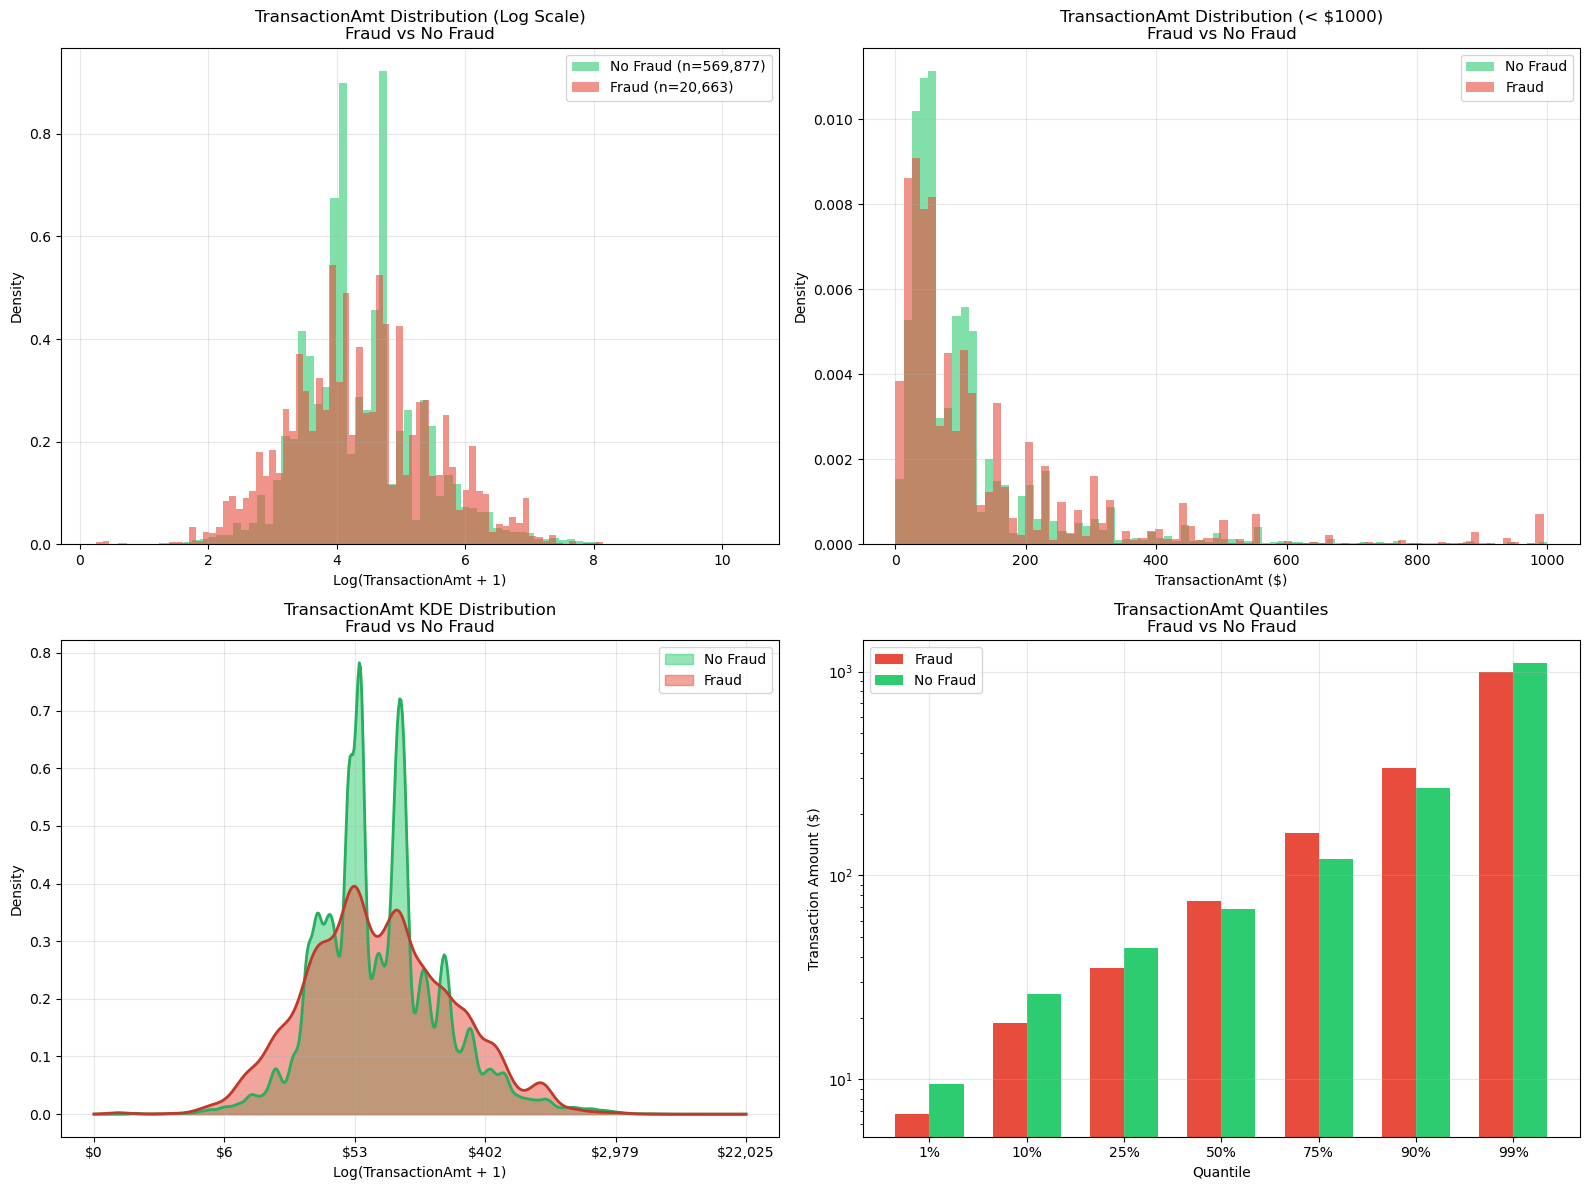

TransactionAmt - İSTATİSTİKSEL ÖZET
Metric                 No Fraud           Fraud            Fark
--------------------------------------------------------------------------------
Count                   569,877          20,663
Mean            $        134.51 $        149.24 $         14.73
Median          $         68.50 $         75.00 $          6.50
Std             $        239.40 $        232.21
Min             $          0.25 $          0.29
Max             $     31,937.39 $      5,191.00

📊 Kolmogorov-Smirnov Test:
   KS Statistic: 0.0756
   P-value: 1.09e-99
   Sonuç: Dağılımlar anlamlı şekilde FARKLI ✓


In [ ]:
# =============================================================================
# TransactionAmt Dağılım Analizi - Fraud vs No Fraud (HİSTOGRAM)
# =============================================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Fraud ve No Fraud verilerini ayır
fraud_amt = df[df['isFraud'] == 1]['TransactionAmt']
nofraud_amt = df[df['isFraud'] == 0]['TransactionAmt']

# 1. Histogram - Log Scale (Overlapping)
ax1 = axes[0, 0]
ax1.hist(np.log1p(nofraud_amt), bins=80, alpha=0.6, color='#2ecc71', label=f'No Fraud (n={len(nofraud_amt):,})', density=True)
ax1.hist(np.log1p(fraud_amt), bins=80, alpha=0.6, color='#e74c3c', label=f'Fraud (n={len(fraud_amt):,})', density=True)
ax1.set_xlabel('Log(TransactionAmt + 1)')
ax1.set_ylabel('Density')
ax1.set_title('TransactionAmt Distribution (Log Scale)\nFraud vs No Fraud')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. Histogram - Original Scale (clipped at 1000 for visibility)
ax2 = axes[0, 1]
clip_value = 1000
ax2.hist(nofraud_amt[nofraud_amt < clip_value], bins=80, alpha=0.6, color='#2ecc71', label='No Fraud', density=True)
ax2.hist(fraud_amt[fraud_amt < clip_value], bins=80, alpha=0.6, color='#e74c3c', label='Fraud', density=True)
ax2.set_xlabel('TransactionAmt ($)')
ax2.set_ylabel('Density')
ax2.set_title(f'TransactionAmt Distribution (< ${clip_value})\nFraud vs No Fraud')
ax2.legend()
ax2.grid(True, alpha=0.3)

# 3. KDE Plot (Daha pürüzsüz dağılım)
ax3 = axes[1, 0]
from scipy import stats
x_range = np.linspace(0, 10, 500)  # log scale range

# KDE hesapla
nofraud_kde = stats.gaussian_kde(np.log1p(nofraud_amt))
fraud_kde = stats.gaussian_kde(np.log1p(fraud_amt))

ax3.fill_between(x_range, nofraud_kde(x_range), alpha=0.5, color='#2ecc71', label='No Fraud')
ax3.fill_between(x_range, fraud_kde(x_range), alpha=0.5, color='#e74c3c', label='Fraud')
ax3.plot(x_range, nofraud_kde(x_range), color='#27ae60', linewidth=2)
ax3.plot(x_range, fraud_kde(x_range), color='#c0392b', linewidth=2)
ax3.set_xlabel('Log(TransactionAmt + 1)')
ax3.set_ylabel('Density')
ax3.set_title('TransactionAmt KDE Distribution\nFraud vs No Fraud')
ax3.legend()
ax3.grid(True, alpha=0.3)

# X ekseni etiketlerini gerçek değerlere çevir
x_ticks = [0, 2, 4, 6, 8, 10]
ax3.set_xticks(x_ticks)
ax3.set_xticklabels([f'${int(np.expm1(x)):,}' for x in x_ticks])

# 4. Quantile karşılaştırması (önceki grafik - sadeleştirilmiş)
ax4 = axes[1, 1]
quantiles = [.01, .1, .25, .5, .75, .9, .99]
fraud_q = fraud_amt.quantile(quantiles)
nofraud_q = nofraud_amt.quantile(quantiles)

x = np.arange(len(quantiles))
width = 0.35
ax4.bar(x - width/2, fraud_q.values, width, label='Fraud', color='#e74c3c')
ax4.bar(x + width/2, nofraud_q.values, width, label='No Fraud', color='#2ecc71')
ax4.set_xlabel('Quantile')
ax4.set_ylabel('Transaction Amount ($)')
ax4.set_title('TransactionAmt Quantiles\nFraud vs No Fraud')
ax4.set_xticks(x)
ax4.set_xticklabels([f'{int(q*100)}%' for q in quantiles])
ax4.legend()
ax4.set_yscale('log')
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# İstatistiksel Özet
print("="*80)
print("TransactionAmt - İSTATİSTİKSEL ÖZET")
print("="*80)
print(f"{'Metric':<15} {'No Fraud':>15} {'Fraud':>15} {'Fark':>15}")
print("-"*80)
print(f"{'Count':<15} {len(nofraud_amt):>15,} {len(fraud_amt):>15,}")
print(f"{'Mean':<15} ${nofraud_amt.mean():>14,.2f} ${fraud_amt.mean():>14,.2f} ${fraud_amt.mean() - nofraud_amt.mean():>14,.2f}")
print(f"{'Median':<15} ${nofraud_amt.median():>14,.2f} ${fraud_amt.median():>14,.2f} ${fraud_amt.median() - nofraud_amt.median():>14,.2f}")
print(f"{'Std':<15} ${nofraud_amt.std():>14,.2f} ${fraud_amt.std():>14,.2f}")
print(f"{'Min':<15} ${nofraud_amt.min():>14,.2f} ${fraud_amt.min():>14,.2f}")
print(f"{'Max':<15} ${nofraud_amt.max():>14,.2f} ${fraud_amt.max():>14,.2f}")
print("="*80)


yuzde 50 ole 99 arasinda ki degerlerde fraud islemleri normal harcamalardan yukardayken digerlerinde assagida kalmakta

In [24]:
# Card Features - Summary Statistics Table
card_cols = ['card1', 'card2', 'card3', 'card4', 'card5', 'card6']

card_summary = []
for col in card_cols:
    if col in df.columns:
        # Calculate entropy
        value_counts = df[col].value_counts(normalize=True, dropna=True)
        entropy = -np.sum(value_counts * np.log2(value_counts + 1e-10))
        
        # Get first 3 non-null values
        non_null_values = df[col].dropna().head(3).tolist()
        first_val = non_null_values[0] if len(non_null_values) > 0 else None
        second_val = non_null_values[1] if len(non_null_values) > 1 else None
        third_val = non_null_values[2] if len(non_null_values) > 2 else None
        
        card_summary.append({
            'Name': col,
            'dtypes': str(df[col].dtype),
            'Missing': df[col].isna().sum(),
            'Uniques': df[col].nunique(),
            'First Value': first_val,
            'Second Value': second_val,
            'Third Value': third_val,
            'Entropy': round(entropy, 2)
        })

card_summary_df = pd.DataFrame(card_summary)
print("="*100)
print("CARD FEATURES - SUMMARY STATISTICS")
print("="*100)
print(card_summary_df.to_string(index=True))
print("="*100)

CARD FEATURES - SUMMARY STATISTICS
    Name    dtypes  Missing  Uniques First Value Second Value Third Value  Entropy
0  card1     int64        0    13553       13926         2755        4663     9.97
1  card2     Int16     8933      500         404          490         567     6.32
2  card3     Int16     1565      114         150          150         150     0.68
3  card4  category     1577        4    discover   mastercard        visa     1.09
4  card5     Int16     4259      119         142          102         166     2.66
5  card6  category     1571        4      credit       credit       debit     0.82


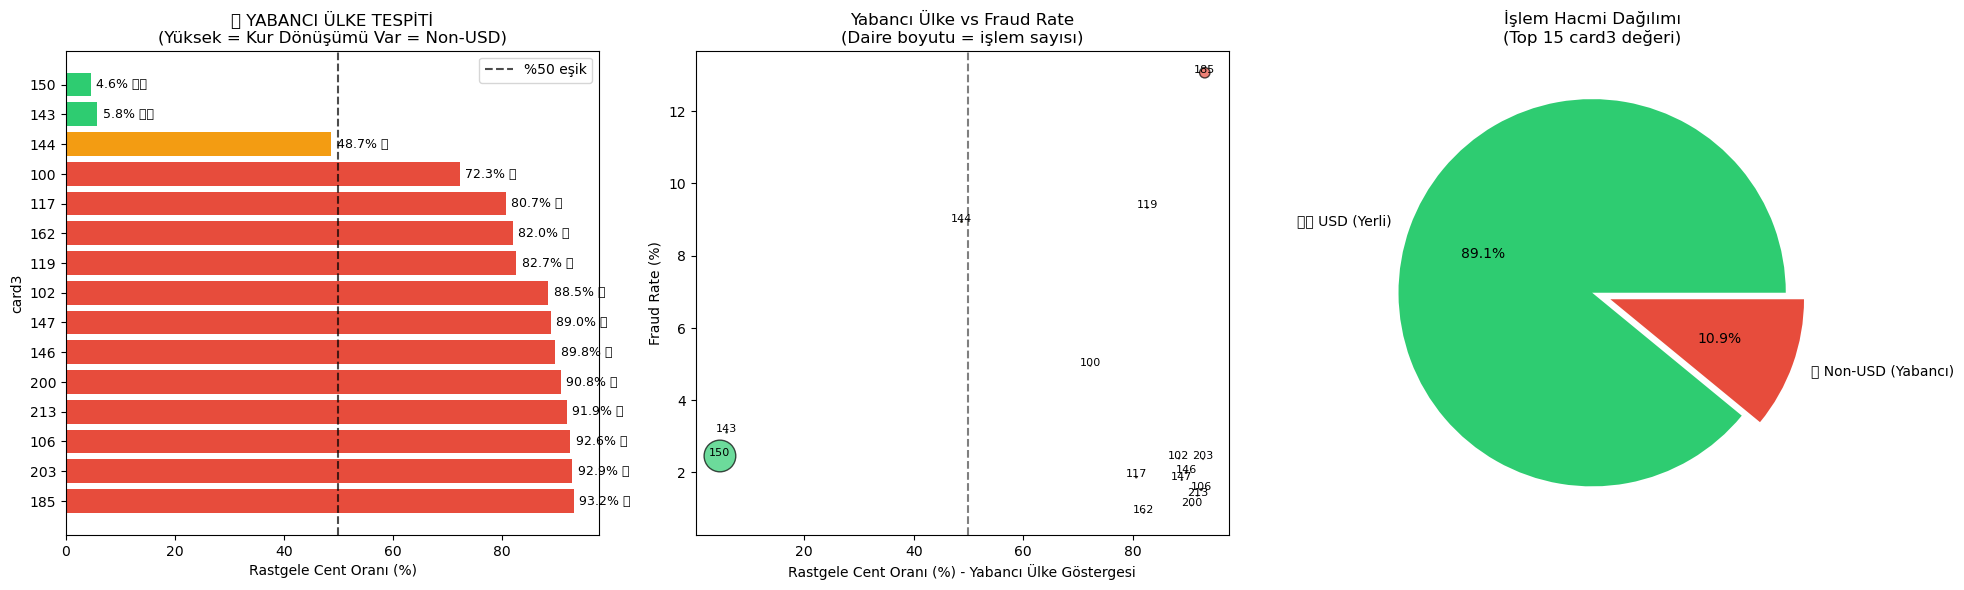

YABANCI ÜLKE TESPİTİ - CARD3 ANALİZİ
Mantık: USD pattern'leri (.00, .25, .49, .50, .75, .90, .95, .99) DIŞINDA kalan cent oranı
        Yüksek oran = Kur dönüşümü var = Yabancı para birimi kullanıyor

   card3        Count    Random%     Fraud%       AvgAmt               Tespit
--------------------------------------------------------------------------------
     185       56,346      93.2%     13.07% $     42.27    YABANCI (Non-USD)
     203          253      92.9%      2.37% $     45.49    YABANCI (Non-USD)
     106        1,571      92.6%      1.53% $     46.49    YABANCI (Non-USD)
     213          221      91.9%      1.36% $     48.98    YABANCI (Non-USD)
     200          184      90.8%      1.09% $     58.35    YABANCI (Non-USD)
     146        1,252      89.8%      2.00% $     45.53    YABANCI (Non-USD)
     147          390      89.0%      1.79% $     48.91    YABANCI (Non-USD)
     102          460      88.5%      2.39% $     43.48    YABANCI (Non-USD)
     119          750   

In [ ]:
# =============================================================================
# CARD3 - YABANCI ÜLKE TESPİTİ (USD Pattern'leri DIŞINDA kalanların yoğunluğu)
# =============================================================================
# Mantık: USD işlemleri belirli cent değerlerinde yoğunlaşır (.00, .50, .99, .95, .49, .90, .25, .75)
#         Kur dönüşümü yapan ülkelerde cent değerleri RASTGELE dağılır

# Ondalık hesapla
df['amt_decimal'] = df['TransactionAmt'] % 1
df['cents'] = (df['amt_decimal'] * 100).round().astype(int)

# USD'nin tipik cent değerleri (psikolojik fiyatlama + yuvarlak)
usd_typical_cents = [0, 25, 49, 50, 75, 90, 95, 99]

# "Rastgele" cent değerleri = USD pattern'leri dışındakiler
df['is_random_cent'] = ~df['cents'].isin(usd_typical_cents)

# card3 analizi
card3_values = df['card3'].value_counts().head(15).index.tolist()

# Her card3 için rastgele cent oranı
random_cent_analysis = []
for card_val in card3_values:
    subset = df[df['card3'] == card_val]
    random_pct = subset['is_random_cent'].mean() * 100
    fraud_rate = subset['isFraud'].mean() * 100
    avg_amt = subset['TransactionAmt'].mean()
    
    random_cent_analysis.append({
        'card3': card_val,
        'count': len(subset),
        'random_cent_pct': random_pct,
        'fraud_rate': fraud_rate,
        'avg_amt': avg_amt
    })

analysis_df = pd.DataFrame(random_cent_analysis).sort_values('random_cent_pct', ascending=False)

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 1. Random Cent Oranı (Yabancı Ülke Göstergesi)
ax1 = axes[0]
colors = ['#e74c3c' if x > 60 else '#f39c12' if x > 40 else '#2ecc71' for x in analysis_df['random_cent_pct']]
bars = ax1.barh(analysis_df['card3'].astype(str), analysis_df['random_cent_pct'], color=colors)
ax1.axvline(x=50, color='black', linestyle='--', alpha=0.7, label='%50 eşik')
ax1.set_xlabel('Rastgele Cent Oranı (%)')
ax1.set_ylabel('card3')
ax1.set_title('🌍 YABANCI ÜLKE TESPİTİ\n(Yüksek = Kur Dönüşümü Var = Non-USD)')
ax1.legend()

for bar, row in zip(bars, analysis_df.itertuples()):
    label = "🌍" if row.random_cent_pct > 60 else "❓" if row.random_cent_pct > 40 else "🇺🇸"
    ax1.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2, 
             f'{row.random_cent_pct:.1f}% {label}', va='center', fontsize=9)

# 2. Fraud Rate vs Random Cent
ax2 = axes[1]
scatter_colors = ['#e74c3c' if x > 60 else '#f39c12' if x > 40 else '#2ecc71' for x in analysis_df['random_cent_pct']]
ax2.scatter(analysis_df['random_cent_pct'], analysis_df['fraud_rate'], 
            s=analysis_df['count']/1000, c=scatter_colors, alpha=0.7, edgecolors='black')
ax2.set_xlabel('Rastgele Cent Oranı (%) - Yabancı Ülke Göstergesi')
ax2.set_ylabel('Fraud Rate (%)')
ax2.set_title('Yabancı Ülke vs Fraud Rate\n(Daire boyutu = işlem sayısı)')
ax2.axvline(x=50, color='black', linestyle='--', alpha=0.5)

for _, row in analysis_df.iterrows():
    ax2.annotate(str(int(row['card3'])), (row['random_cent_pct'], row['fraud_rate']), 
                fontsize=8, ha='center')

# 3. İşlem Hacmi Dağılımı
ax3 = axes[2]
foreign_mask = analysis_df['random_cent_pct'] > 25
domestic = analysis_df[~foreign_mask]['count'].sum()
foreign = analysis_df[foreign_mask]['count'].sum()

ax3.pie([domestic, foreign], labels=['🇺🇸 USD (Yerli)', '🌍 Non-USD (Yabancı)'], 
        autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'], explode=[0, 0.1])
ax3.set_title(f'İşlem Hacmi Dağılımı\n(Top 15 card3 değeri)')

plt.tight_layout()
plt.show()

# Detaylı Tablo
print("="*100)
print("YABANCI ÜLKE TESPİTİ - CARD3 ANALİZİ")
print("="*100)
print("Mantık: USD pattern'leri (.00, .25, .49, .50, .75, .90, .95, .99) DIŞINDA kalan cent oranı")
print("        Yüksek oran = Kur dönüşümü var = Yabancı para birimi kullanıyor")
print("="*100)

print(f"\n{'card3':>8} {'Count':>12} {'Random%':>10} {'Fraud%':>10} {'AvgAmt':>12} {'Tespit':>20}")
print("-"*80)

for _, row in analysis_df.iterrows():
    if row['random_cent_pct'] > 60:
        tespit = " YABANCI (Non-USD)"
    elif row['random_cent_pct'] > 40:
        tespit = " KARISIK"
    else:
        tespit = "🇺🇸 YERLİ (USD)"
    
    print(f"{int(row['card3']):>8} {int(row['count']):>12,} {row['random_cent_pct']:>9.1f}% {row['fraud_rate']:>9.2f}% ${row['avg_amt']:>10.2f} {tespit:>20}")

# Temizlik
df.drop(['amt_decimal', 'cents', 'is_random_cent'], axis=1, inplace=True)
print("="*100)

ValueError: supplied range of [-inf, 6.779922008514404] is not finite

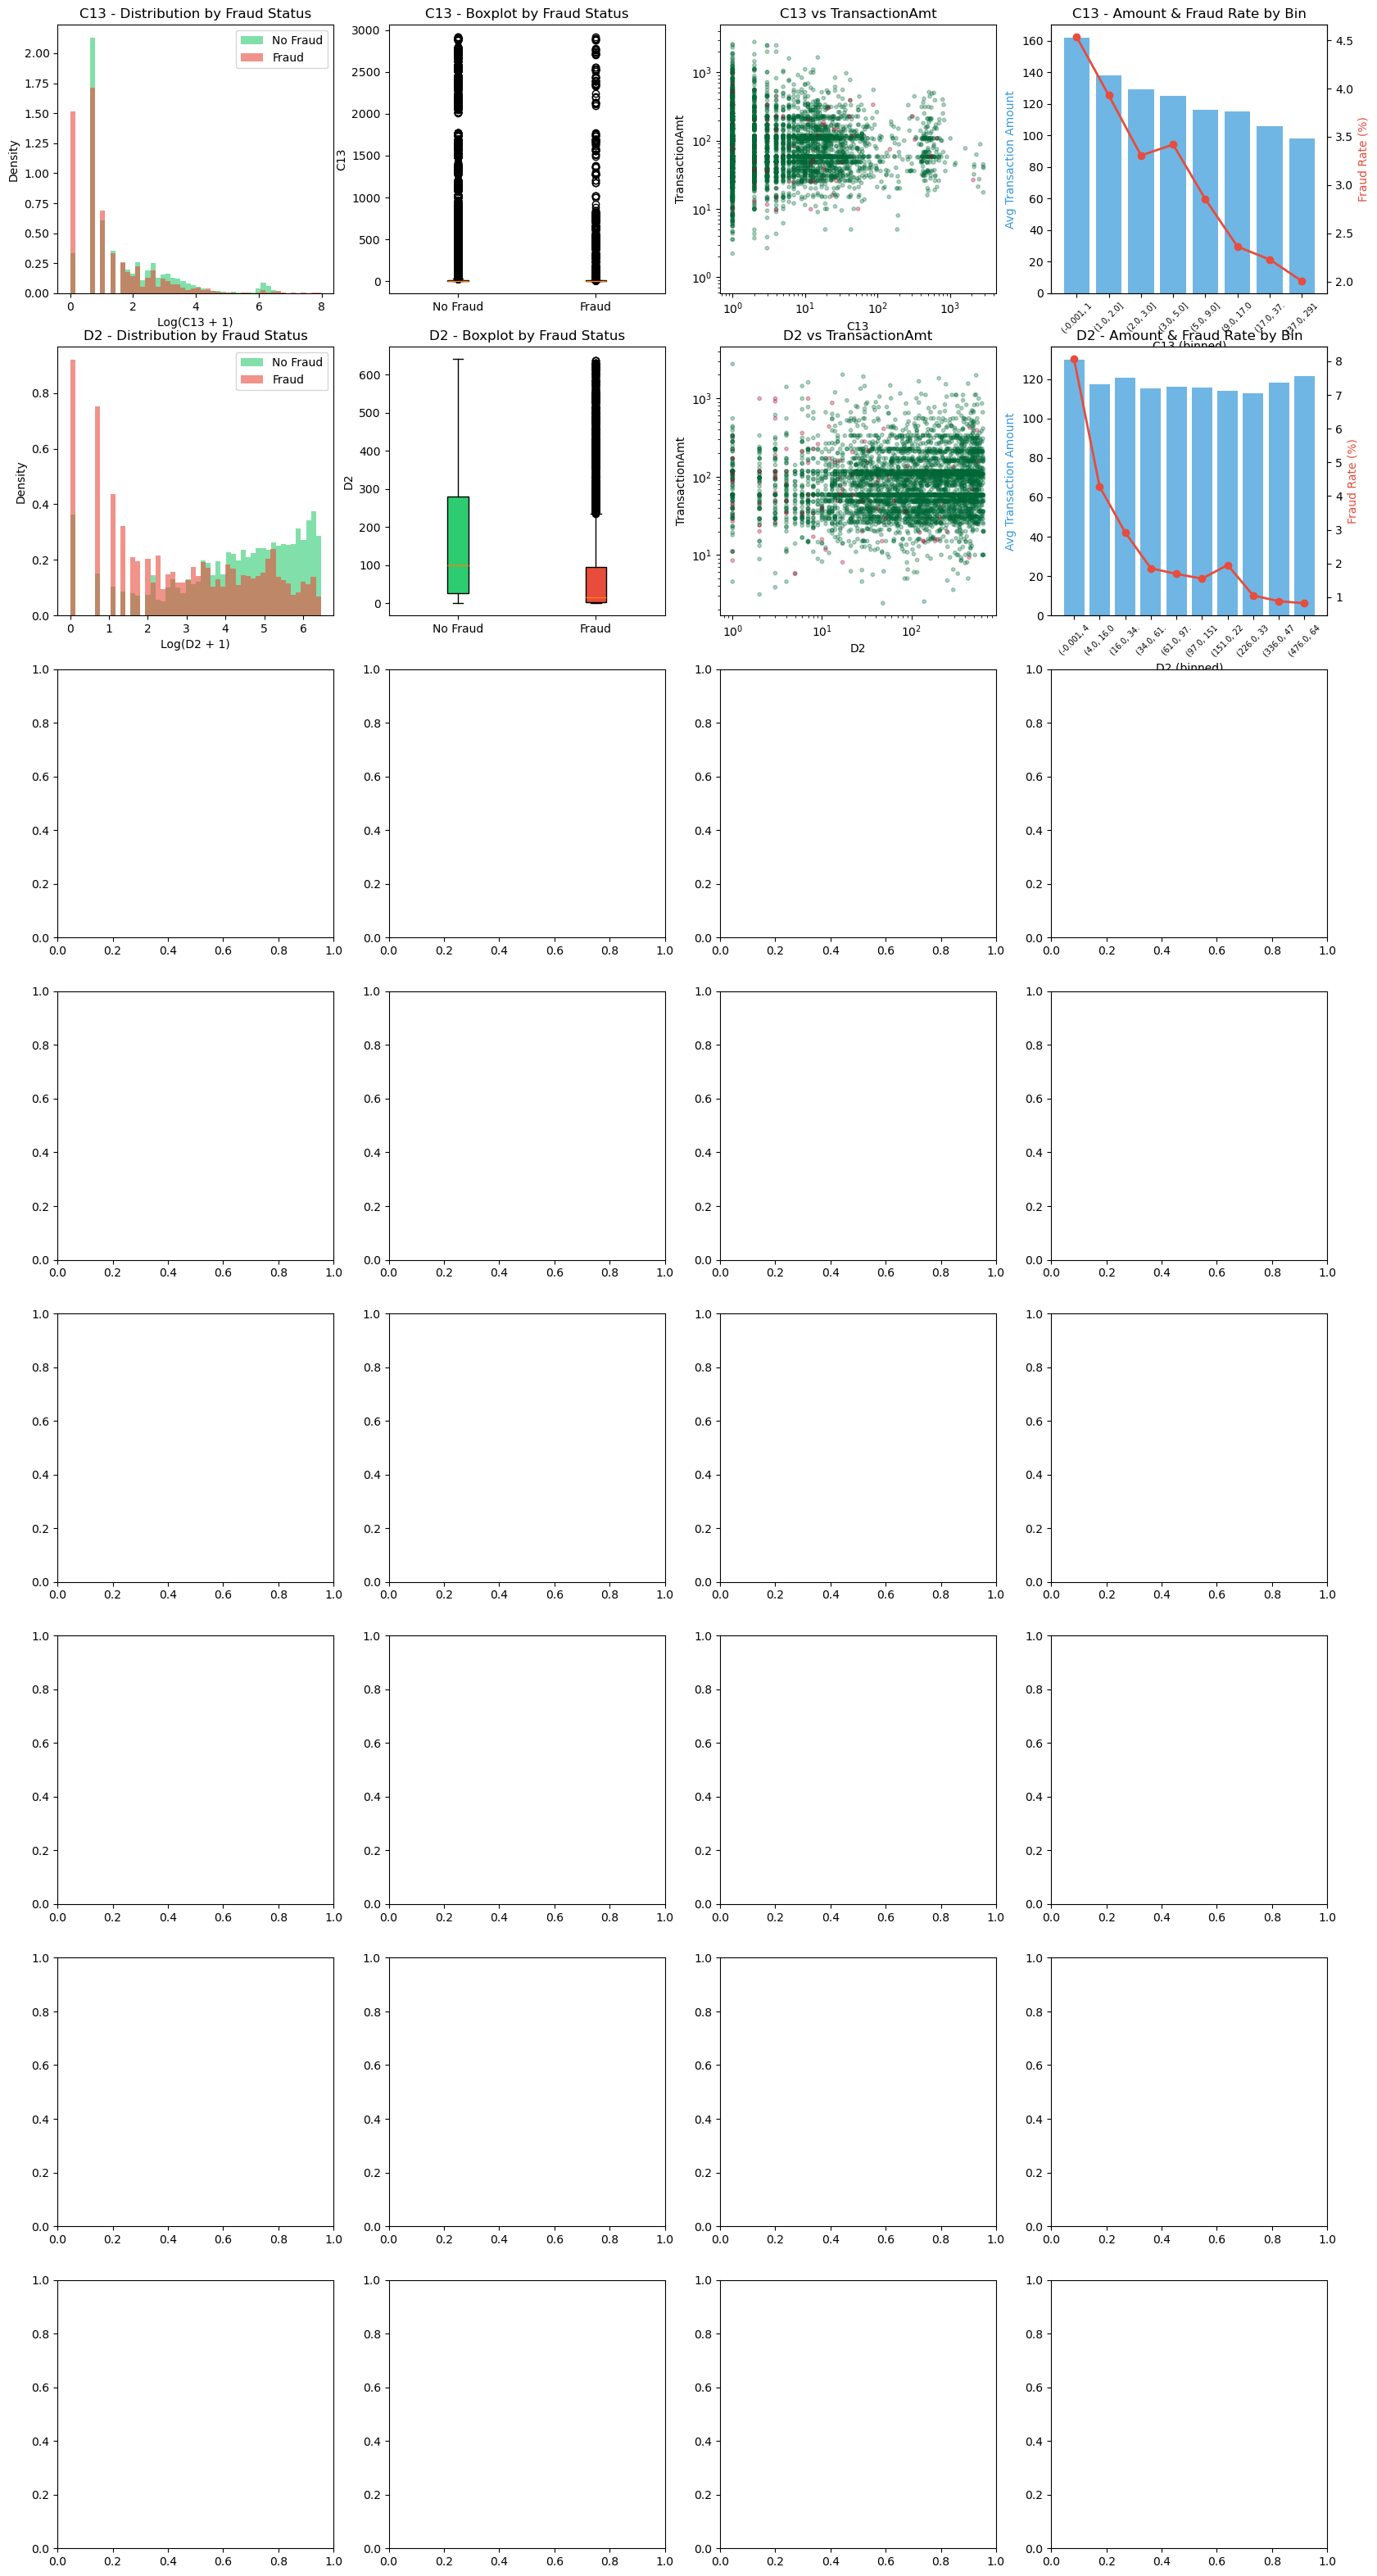

In [13]:
# C13, D2, D15, C1, D4, D1, D10, C14 - Histogram & Boxplot Analysis
# Fraud distribution and Transaction Amount relationship
target_cols = ['C13', 'D2', 'D15', 'C1', 'D4', 'D1', 'D10', 'C14']
fig, axes = plt.subplots(len(target_cols), 4, figsize=(20, 5 * len(target_cols)))

for idx, col in enumerate(target_cols):
    # 1. Histogram by Fraud Status
    ax1 = axes[idx, 0]
    for fraud_val, color, label in [(0, '#2ecc71', 'No Fraud'), (1, '#e74c3c', 'Fraud')]:
        data = df[df['isFraud'] == fraud_val][col].dropna()
        if len(data) > 0:
            # Use log scale if data has high range
            if data.max() > 100:
                ax1.hist(np.log1p(data), bins=50, alpha=0.6, color=color, label=label, density=True)
                ax1.set_xlabel(f'Log({col} + 1)')
            else:
                ax1.hist(data, bins=50, alpha=0.6, color=color, label=label, density=True)
                ax1.set_xlabel(col)
    ax1.set_ylabel('Density')
    ax1.set_title(f'{col} - Distribution by Fraud Status')
    ax1.legend()
    
    # 2. Boxplot by Fraud Status
    ax2 = axes[idx, 1]
    fraud_data = [df[df['isFraud'] == 0][col].dropna(), df[df['isFraud'] == 1][col].dropna()]
    bp = ax2.boxplot(fraud_data, labels=['No Fraud', 'Fraud'], patch_artist=True)
    bp['boxes'][0].set_facecolor('#2ecc71')
    bp['boxes'][1].set_facecolor('#e74c3c')
    ax2.set_ylabel(col)
    ax2.set_title(f'{col} - Boxplot by Fraud Status')
    
    # 3. Scatter plot with Transaction Amount
    ax3 = axes[idx, 2]
    sample = df[[col, 'TransactionAmt', 'isFraud']].dropna().sample(min(5000, len(df)), random_state=42)
    scatter = ax3.scatter(sample[col], sample['TransactionAmt'], 
                          c=sample['isFraud'], cmap='RdYlGn_r', alpha=0.3, s=10)
    ax3.set_xlabel(col)
    ax3.set_ylabel('TransactionAmt')
    ax3.set_title(f'{col} vs TransactionAmt')
    if sample[col].max() > 100:
        ax3.set_xscale('log')
    ax3.set_yscale('log')
    
    # 4. Mean Transaction Amount by binned feature
    ax4 = axes[idx, 3]
    col_data = df[[col, 'TransactionAmt', 'isFraud']].dropna()
    try:
        col_data['bin'] = pd.qcut(col_data[col], q=10, duplicates='drop')
        amt_by_bin = col_data.groupby('bin').agg({
            'TransactionAmt': 'mean',
            'isFraud': 'mean'
        }).reset_index()
        
        ax4_twin = ax4.twinx()
        x_pos = range(len(amt_by_bin))
        ax4.bar(x_pos, amt_by_bin['TransactionAmt'], color='#3498db', alpha=0.7, label='Avg Amount')
        ax4_twin.plot(x_pos, amt_by_bin['isFraud'] * 100, 'o-', color='#e74c3c', linewidth=2, label='Fraud Rate')
        
        ax4.set_xlabel(f'{col} (binned)')
        ax4.set_ylabel('Avg Transaction Amount', color='#3498db')
        ax4_twin.set_ylabel('Fraud Rate (%)', color='#e74c3c')
        ax4.set_title(f'{col} - Amount & Fraud Rate by Bin')
        ax4.tick_params(axis='x', rotation=45)
        ax4.set_xticks(x_pos)
        ax4.set_xticklabels([str(b)[:10] for b in amt_by_bin['bin']], fontsize=7)
    except:
        ax4.text(0.5, 0.5, 'Cannot bin\n(too few unique values)', ha='center', va='center', transform=ax4.transAxes)
        ax4.set_title(f'{col} - Binning Failed')

plt.tight_layout()
plt.show()

# Summary statistics
print("="*80)
print("SUMMARY STATISTICS")
print("="*80)
for col in target_cols:
    fraud_median = df[df['isFraud'] == 1][col].median()
    nofraud_median = df[df['isFraud'] == 0][col].median()
    missing_pct = df[col].isna().mean() * 100
    print(f"{col:6s} | Missing: {missing_pct:5.1f}% | Median (NoFraud): {nofraud_median:10.2f} | Median (Fraud): {fraud_median:10.2f}")

## 3. Missing Values Analysis

In [ ]:
# Missing values by feature group
missing_by_group = {}

for group, cols in feature_groups.items():
    existing_cols = [c for c in cols if c in df.columns]
    if existing_cols:
        missing_pct = df[existing_cols].isnull().mean().mean() * 100
        missing_by_group[group] = missing_pct

# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Missing by group
groups = list(missing_by_group.keys())
missing_pcts = list(missing_by_group.values())
colors = ['#e74c3c' if p > 50 else '#f39c12' if p > 20 else '#2ecc71' for p in missing_pcts]

bars = axes[0].barh(groups, missing_pcts, color=colors)
axes[0].set_xlabel('Missing Rate (%)')
axes[0].set_title('Missing Values by Feature Group')
axes[0].axvline(x=50, color='red', linestyle='--', alpha=0.5, label='50% threshold')

for bar, pct in zip(bars, missing_pcts):
    axes[0].text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2, 
                 f'{pct:.1f}%', va='center')

# Top 20 columns with most missing
missing_cols = df.isnull().mean().sort_values(ascending=False).head(20) * 100
axes[1].barh(missing_cols.index, missing_cols.values, color='#e74c3c')
axes[1].set_xlabel('Missing Rate (%)')
axes[1].set_title('Top 20 Columns with Most Missing Values')

plt.tight_layout()
plt.show()

# Summary
print(f"\nColumns with >50% missing: {(df.isnull().mean() > 0.5).sum()}")
print(f"Columns with no missing: {(df.isnull().mean() == 0).sum()}")
print(f"Total missing cells: {df.isnull().sum().sum():,} ({df.isnull().mean().mean()*100:.1f}%)")

NameError: name 'feature_groups' is not defined

## 4. Transaction Amount Analysis

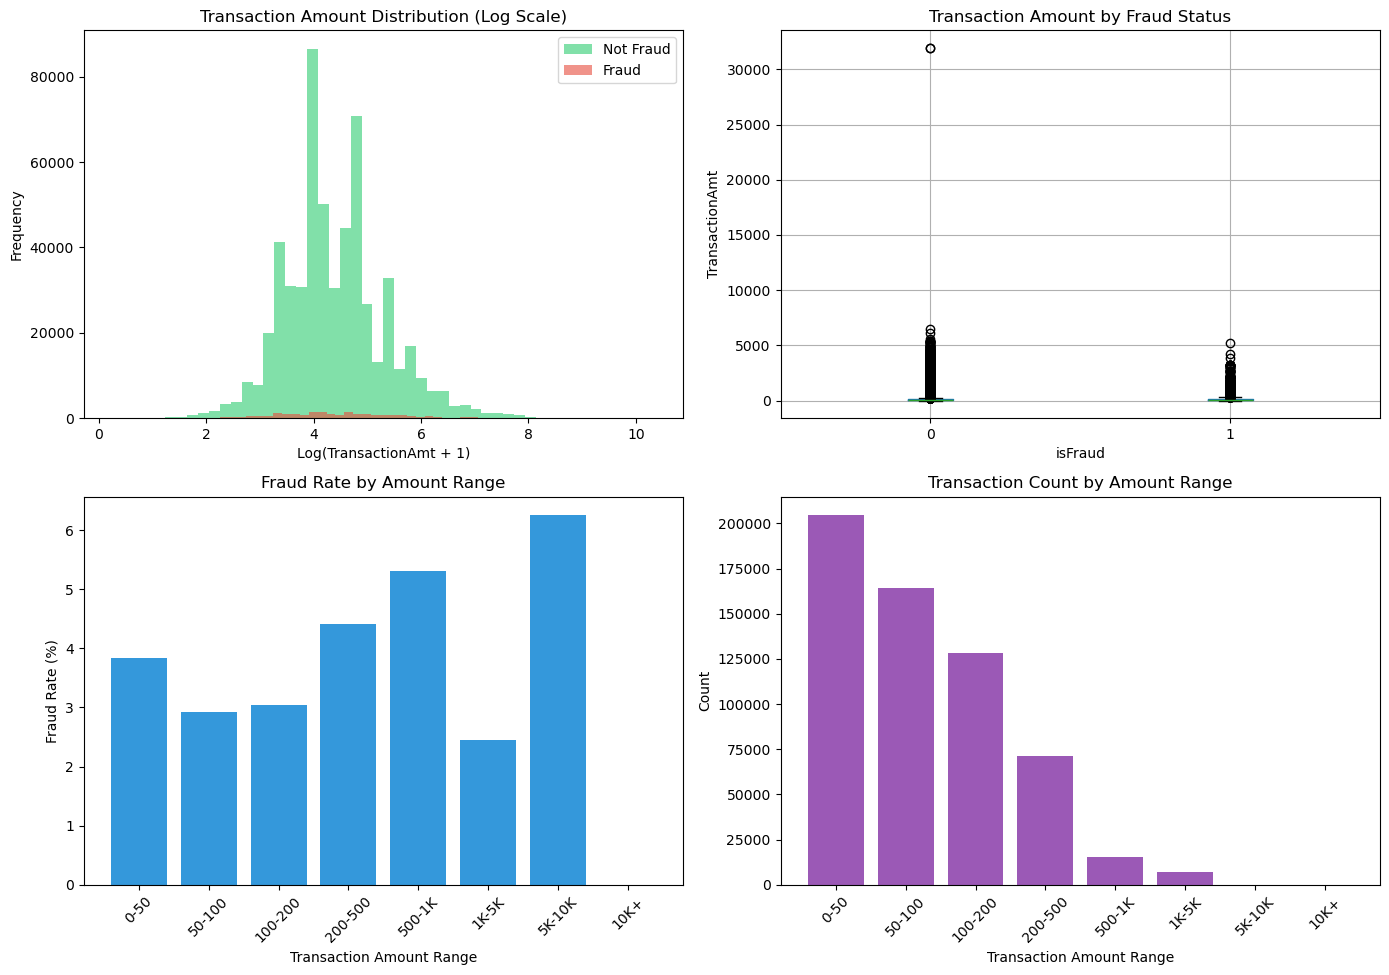


Transaction Amount Statistics:
Metric    Not Fraud       Fraud
  Mean   134.511665  149.244779
Median    68.500000   75.000000
   Std   239.395078  232.212163
   Min     0.251000    0.292000
   Max 31937.391000 5191.000000
   25%    43.970000   35.044000
   75%   120.000000  161.000000


In [ ]:
# Transaction Amount distribution by fraud status
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Distribution (log scale)
for fraud_val, color, label in [(0, '#2ecc71', 'Not Fraud'), (1, '#e74c3c', 'Fraud')]:
    data = df[df['isFraud'] == fraud_val]['TransactionAmt']
    axes[0, 0].hist(np.log1p(data), bins=50, alpha=0.6, color=color, label=label)
axes[0, 0].set_xlabel('Log(TransactionAmt + 1)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Transaction Amount Distribution (Log Scale)')
axes[0, 0].legend()

# Box plot by fraud
df.boxplot(column='TransactionAmt', by='isFraud', ax=axes[0, 1])
axes[0, 1].set_title('Transaction Amount by Fraud Status')
axes[0, 1].set_xlabel('isFraud')
axes[0, 1].set_ylabel('TransactionAmt')
plt.suptitle('')

# Summary statistics
fraud_amt = df[df['isFraud'] == 1]['TransactionAmt']
not_fraud_amt = df[df['isFraud'] == 0]['TransactionAmt']

stats_data = {
    'Metric': ['Mean', 'Median', 'Std', 'Min', 'Max', '25%', '75%'],
    'Not Fraud': [not_fraud_amt.mean(), not_fraud_amt.median(), not_fraud_amt.std(), 
                  not_fraud_amt.min(), not_fraud_amt.max(), not_fraud_amt.quantile(0.25), not_fraud_amt.quantile(0.75)],
    'Fraud': [fraud_amt.mean(), fraud_amt.median(), fraud_amt.std(),
              fraud_amt.min(), fraud_amt.max(), fraud_amt.quantile(0.25), fraud_amt.quantile(0.75)]
}

# Amount ranges fraud rate
bins = [0, 50, 100, 200, 500, 1000, 5000, 10000, float('inf')]
labels = ['0-50', '50-100', '100-200', '200-500', '500-1K', '1K-5K', '5K-10K', '10K+']
df['amt_bin'] = pd.cut(df['TransactionAmt'], bins=bins, labels=labels)

fraud_by_amt = df.groupby('amt_bin')['isFraud'].agg(['mean', 'count'])
fraud_by_amt['mean'] = fraud_by_amt['mean'] * 100

axes[1, 0].bar(fraud_by_amt.index.astype(str), fraud_by_amt['mean'], color='#3498db')
axes[1, 0].set_xlabel('Transaction Amount Range')
axes[1, 0].set_ylabel('Fraud Rate (%)')
axes[1, 0].set_title('Fraud Rate by Amount Range')
axes[1, 0].tick_params(axis='x', rotation=45)

# Transaction count by range
axes[1, 1].bar(fraud_by_amt.index.astype(str), fraud_by_amt['count'], color='#9b59b6')
axes[1, 1].set_xlabel('Transaction Amount Range')
axes[1, 1].set_ylabel('Count')
axes[1, 1].set_title('Transaction Count by Amount Range')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Clean up temp column
df = df.drop('amt_bin', axis=1)

# Print stats
print("\nTransaction Amount Statistics:")
print(pd.DataFrame(stats_data).to_string(index=False))

## 5. Categorical Features - Fraud Rate Analysis

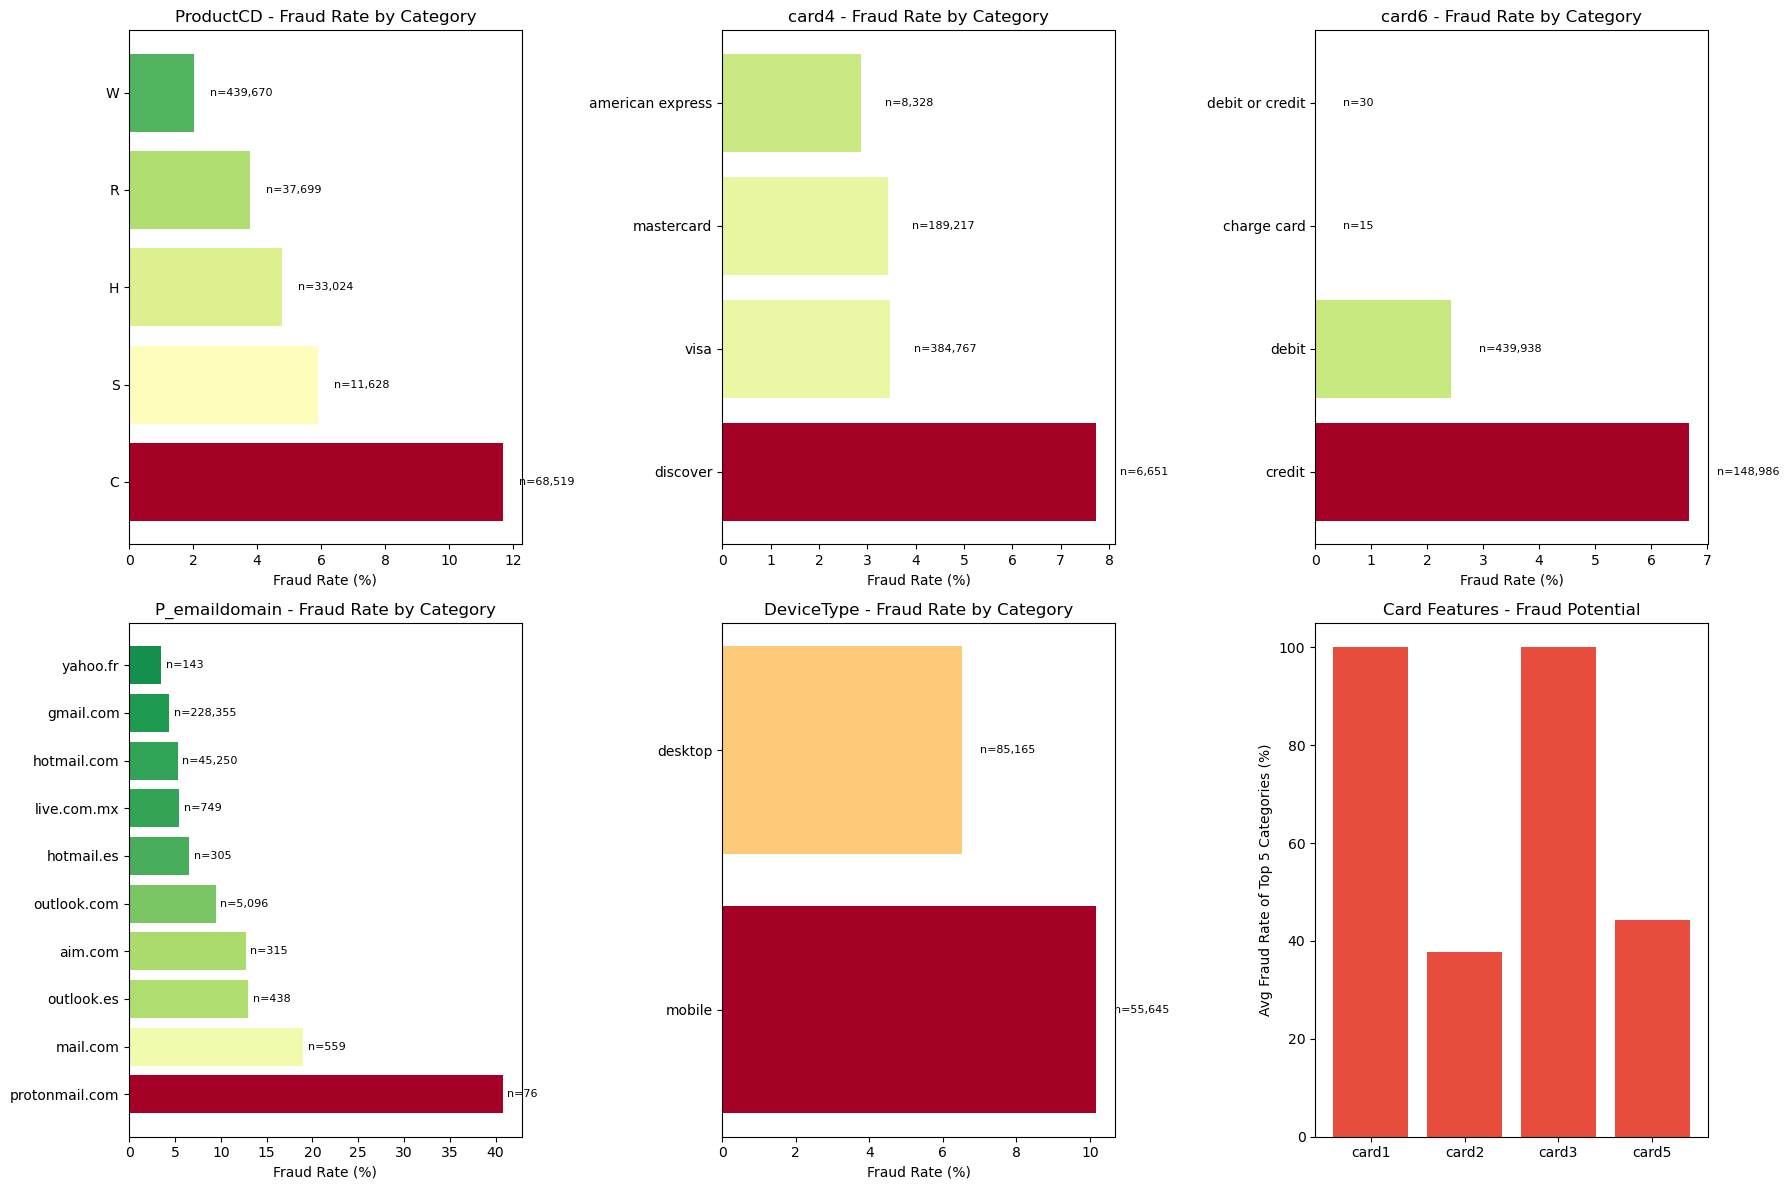

In [ ]:
# Key categorical features fraud analysis
key_cats = ['ProductCD', 'card4', 'card6', 'P_emaildomain', 'DeviceType']
existing_cats = [c for c in key_cats if c in df.columns]

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for idx, col in enumerate(existing_cats):
    # Calculate fraud rate per category
    fraud_rate = df.groupby(col)['isFraud'].agg(['mean', 'count']).reset_index()
    fraud_rate['mean'] = fraud_rate['mean'] * 100
    fraud_rate = fraud_rate.sort_values('mean', ascending=False).head(10)
    
    # Plot
    colors = plt.cm.RdYlGn_r(fraud_rate['mean'] / fraud_rate['mean'].max())
    bars = axes[idx].barh(fraud_rate[col].astype(str), fraud_rate['mean'], color=colors)
    axes[idx].set_xlabel('Fraud Rate (%)')
    axes[idx].set_title(f'{col} - Fraud Rate by Category')
    
    # Add count labels
    for bar, count in zip(bars, fraud_rate['count']):
        axes[idx].text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2, 
                      f'n={count:,}', va='center', fontsize=8)

# Card features (card1-card6)
card_cols = [c for c in df.columns if c.startswith('card') and c in ['card1', 'card2', 'card3', 'card5']]
card_fraud_rates = {}

for col in card_cols:
    # Top 5 fraud rate categories for each card
    top_fraud = df.groupby(col)['isFraud'].mean().nlargest(5).mean() * 100
    card_fraud_rates[col] = top_fraud

axes[5].bar(card_fraud_rates.keys(), card_fraud_rates.values(), color='#e74c3c')
axes[5].set_ylabel('Avg Fraud Rate of Top 5 Categories (%)')
axes[5].set_title('Card Features - Fraud Potential')

plt.tight_layout()
plt.show()

## 6. Time Analysis (TransactionDT)

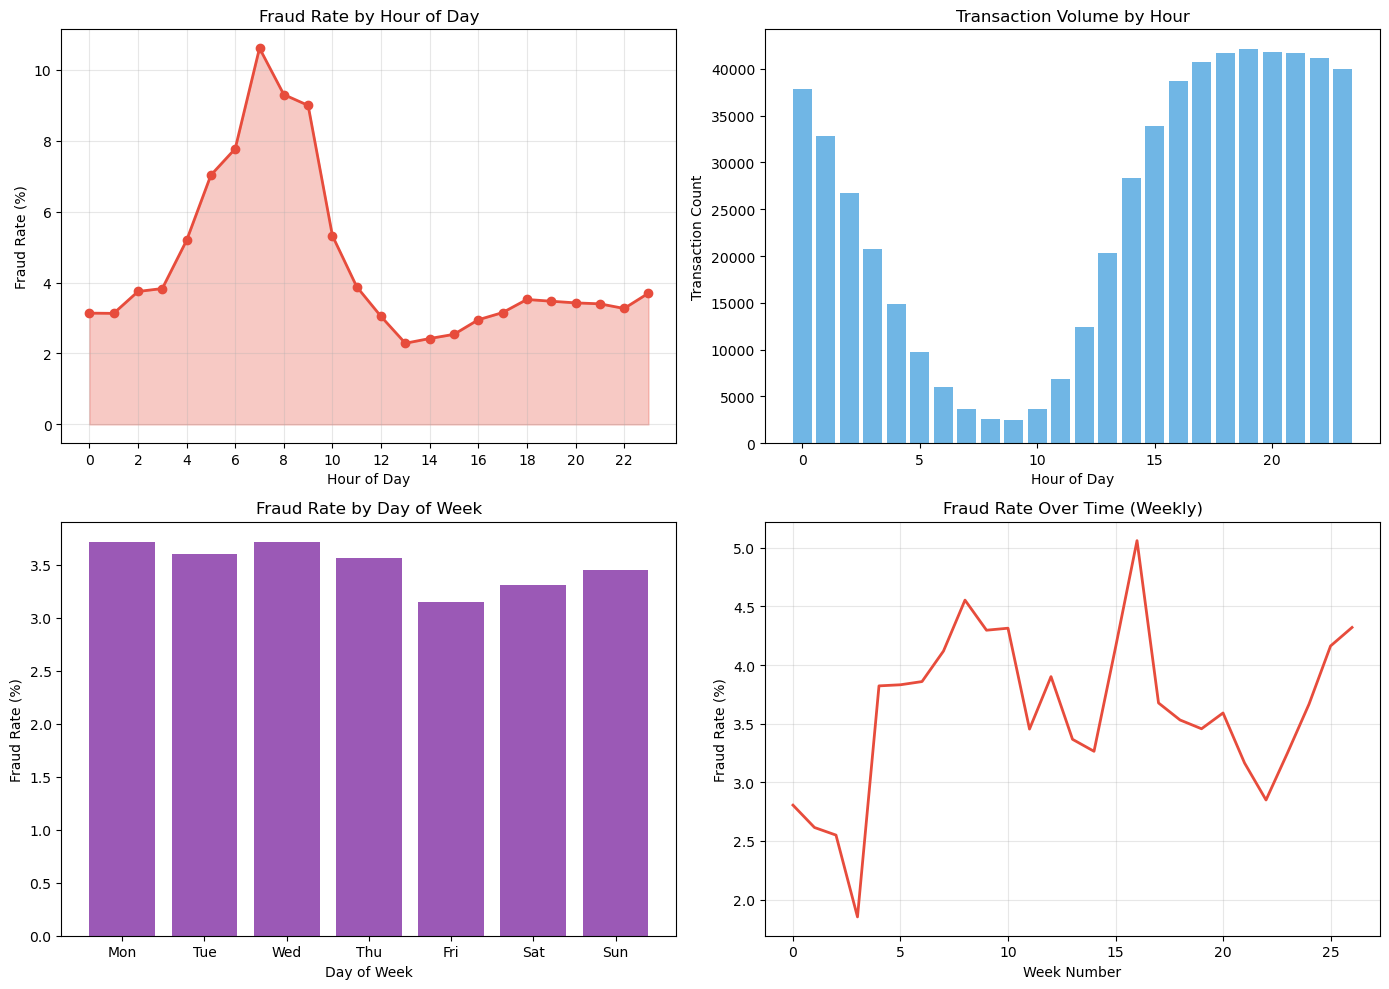


Peak fraud hour: 7:00 (10.61%)
Lowest fraud hour: 13:00 (2.29%)


In [ ]:
# TransactionDT is seconds from a reference datetime
# Extract time features
df['hour'] = (df['TransactionDT'] // 3600) % 24
df['day'] = (df['TransactionDT'] // (3600 * 24)) % 7
df['week'] = df['TransactionDT'] // (3600 * 24 * 7)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Fraud rate by hour
hourly_fraud = df.groupby('hour')['isFraud'].mean() * 100
axes[0, 0].plot(hourly_fraud.index, hourly_fraud.values, marker='o', color='#e74c3c', linewidth=2)
axes[0, 0].fill_between(hourly_fraud.index, hourly_fraud.values, alpha=0.3, color='#e74c3c')
axes[0, 0].set_xlabel('Hour of Day')
axes[0, 0].set_ylabel('Fraud Rate (%)')
axes[0, 0].set_title('Fraud Rate by Hour of Day')
axes[0, 0].set_xticks(range(0, 24, 2))
axes[0, 0].grid(True, alpha=0.3)

# Transaction volume by hour
hourly_count = df.groupby('hour').size()
axes[0, 1].bar(hourly_count.index, hourly_count.values, color='#3498db', alpha=0.7)
axes[0, 1].set_xlabel('Hour of Day')
axes[0, 1].set_ylabel('Transaction Count')
axes[0, 1].set_title('Transaction Volume by Hour')

# Fraud rate by day of week
daily_fraud = df.groupby('day')['isFraud'].mean() * 100
days = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
axes[1, 0].bar(range(7), daily_fraud.values, color='#9b59b6')
axes[1, 0].set_xlabel('Day of Week')
axes[1, 0].set_ylabel('Fraud Rate (%)')
axes[1, 0].set_title('Fraud Rate by Day of Week')
axes[1, 0].set_xticks(range(7))
axes[1, 0].set_xticklabels(days)

# Fraud over time (weeks)
weekly_fraud = df.groupby('week')['isFraud'].mean() * 100
axes[1, 1].plot(weekly_fraud.index, weekly_fraud.values, color='#e74c3c', linewidth=2)
axes[1, 1].set_xlabel('Week Number')
axes[1, 1].set_ylabel('Fraud Rate (%)')
axes[1, 1].set_title('Fraud Rate Over Time (Weekly)')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Clean up temp columns
df = df.drop(['hour', 'day', 'week'], axis=1)

print(f"\nPeak fraud hour: {hourly_fraud.idxmax()}:00 ({hourly_fraud.max():.2f}%)")
print(f"Lowest fraud hour: {hourly_fraud.idxmin()}:00 ({hourly_fraud.min():.2f}%)")

## 7. V Features Correlation Analysis (Vesta Engineered)

In [ ]:
# V features are Vesta-engineered features (V1-V339)
v_cols = [col for col in df.columns if col.startswith('V')]
print(f"Total V features: {len(v_cols)}")

# Correlation with target
v_target_corr = df[v_cols + ['isFraud']].corr()['isFraud'].drop('isFraud').abs().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top 20 V features correlated with fraud
top_v = v_target_corr.head(20)
axes[0].barh(top_v.index, top_v.values, color='#e74c3c')
axes[0].set_xlabel('Absolute Correlation with isFraud')
axes[0].set_title('Top 20 V Features Correlated with Fraud')
axes[0].invert_yaxis()

# V features correlation distribution
axes[1].hist(v_target_corr.values, bins=50, color='#3498db', edgecolor='white')
axes[1].set_xlabel('Absolute Correlation')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of V Feature Correlations with Fraud')
axes[1].axvline(x=0.1, color='red', linestyle='--', label='0.1 threshold')
axes[1].legend()

plt.tight_layout()
plt.show()

# Group V features by correlation strength
high_corr_v = v_target_corr[v_target_corr > 0.1].index.tolist()
med_corr_v = v_target_corr[(v_target_corr > 0.05) & (v_target_corr <= 0.1)].index.tolist()
low_corr_v = v_target_corr[v_target_corr <= 0.05].index.tolist()

print(f"\nV Features by Correlation Strength:")
print(f"  High (>0.1): {len(high_corr_v)} features")
print(f"  Medium (0.05-0.1): {len(med_corr_v)} features")
print(f"  Low (<0.05): {len(low_corr_v)} features")
print(f"\nTop 5 V features: {list(top_v.head(5).index)}")

Total V features: 339


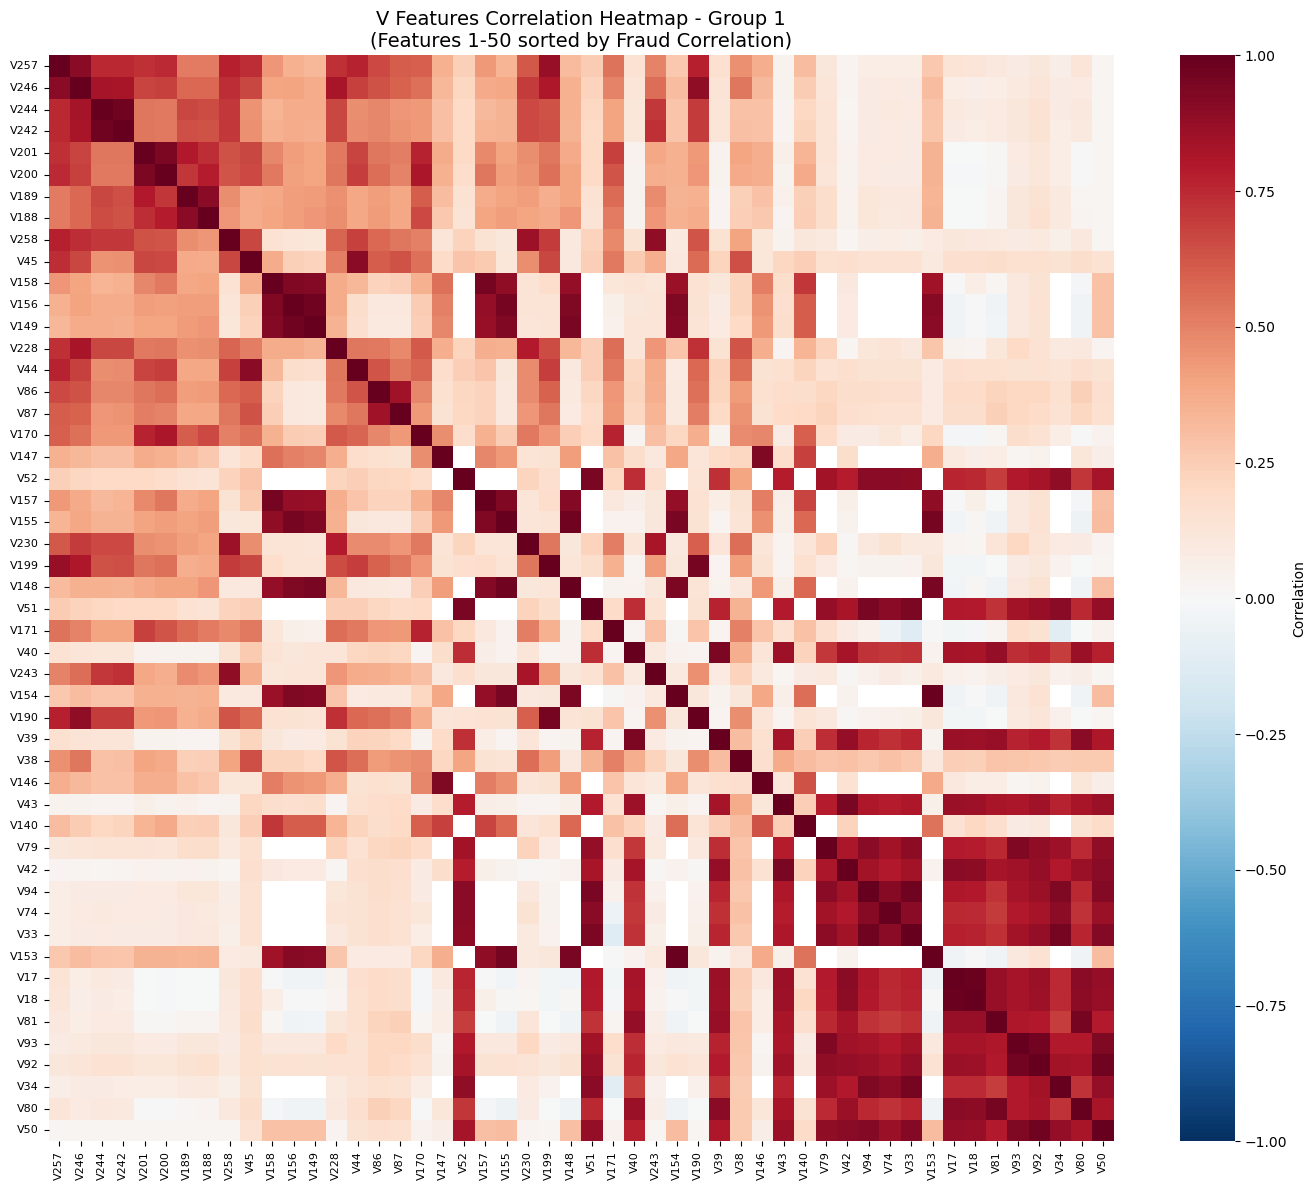


GROUP 1 - Top 5 Most Correlated Feature Pairs
  V17 <-> V18: 0.9915
  V154 <-> V153: 0.9865
  V156 <-> V149: 0.9762
  V155 <-> V148: 0.9760
  V94 <-> V33: 0.9758



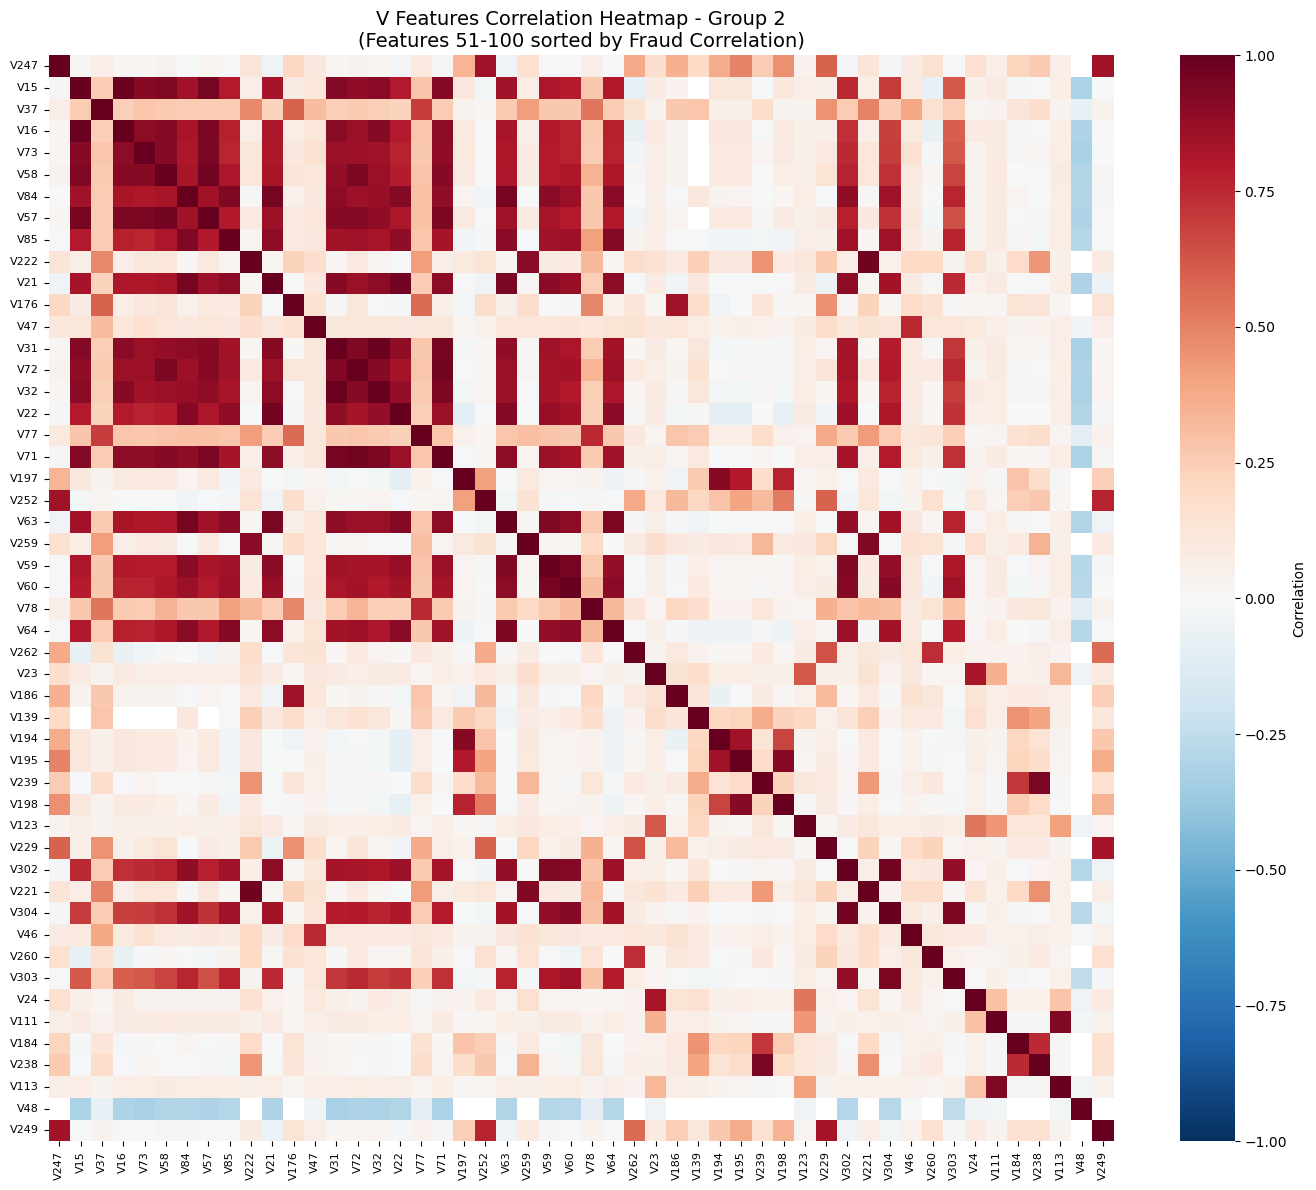


GROUP 2 - Top 5 Most Correlated Feature Pairs
  V15 <-> V16: 0.9867
  V31 <-> V32: 0.9862
  V222 <-> V221: 0.9700
  V21 <-> V22: 0.9646
  V72 <-> V71: 0.9638



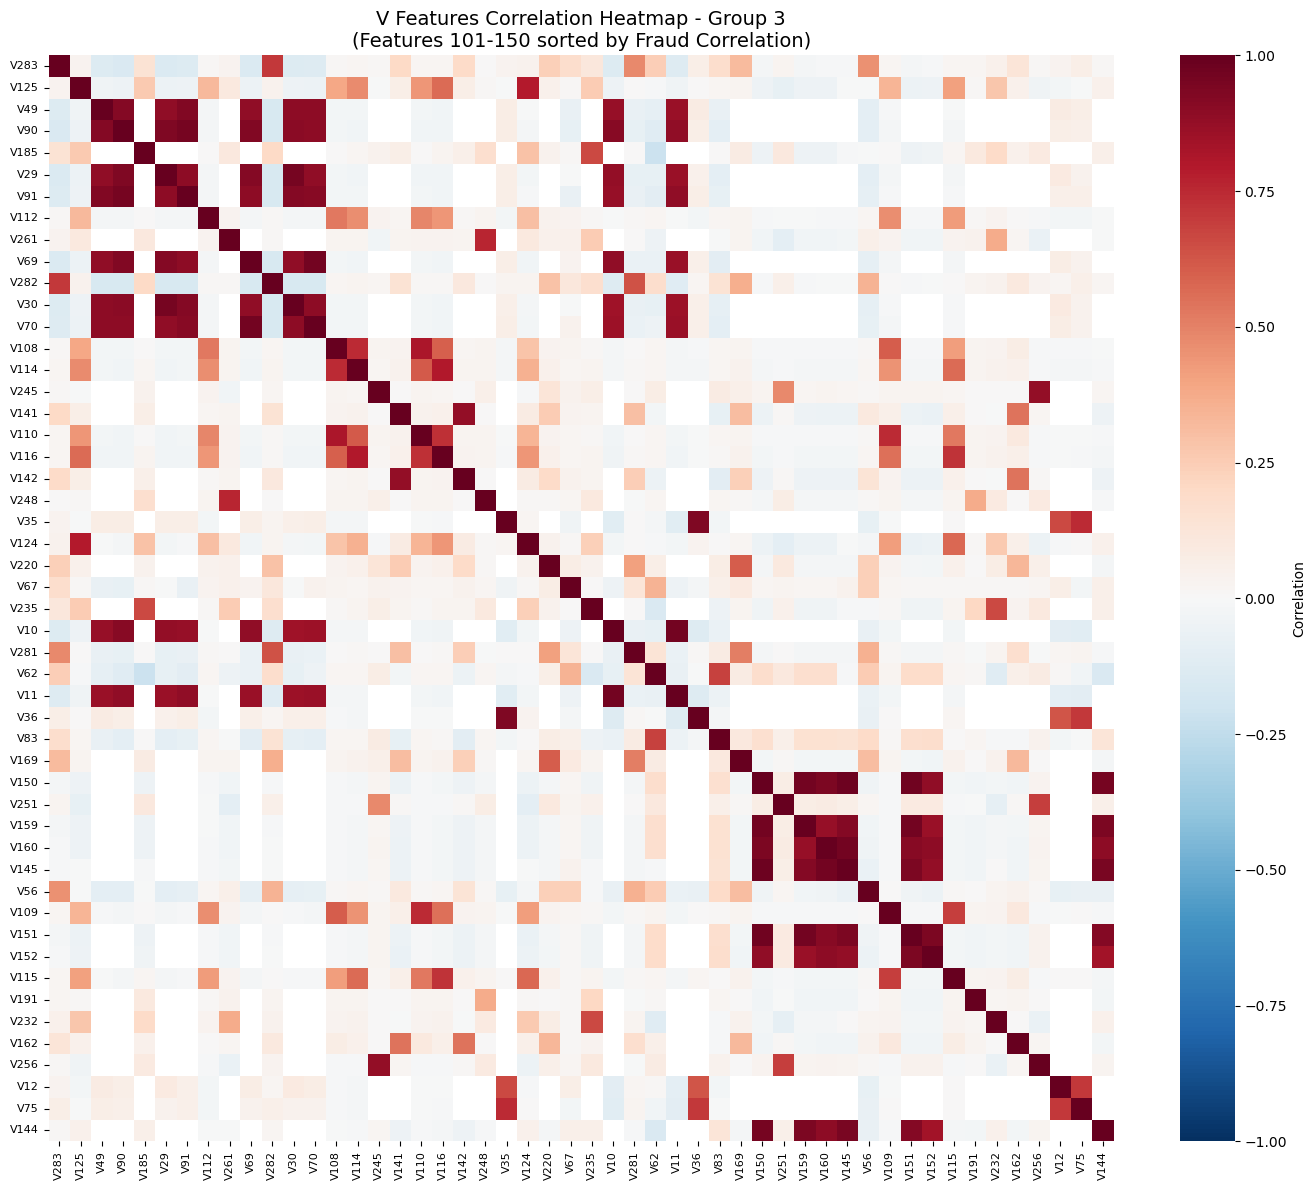


GROUP 3 - Top 5 Most Correlated Feature Pairs
  V150 <-> V145: 0.9818
  V150 <-> V151: 0.9729
  V10 <-> V11: 0.9687
  V150 <-> V159: 0.9685
  V159 <-> V151: 0.9627



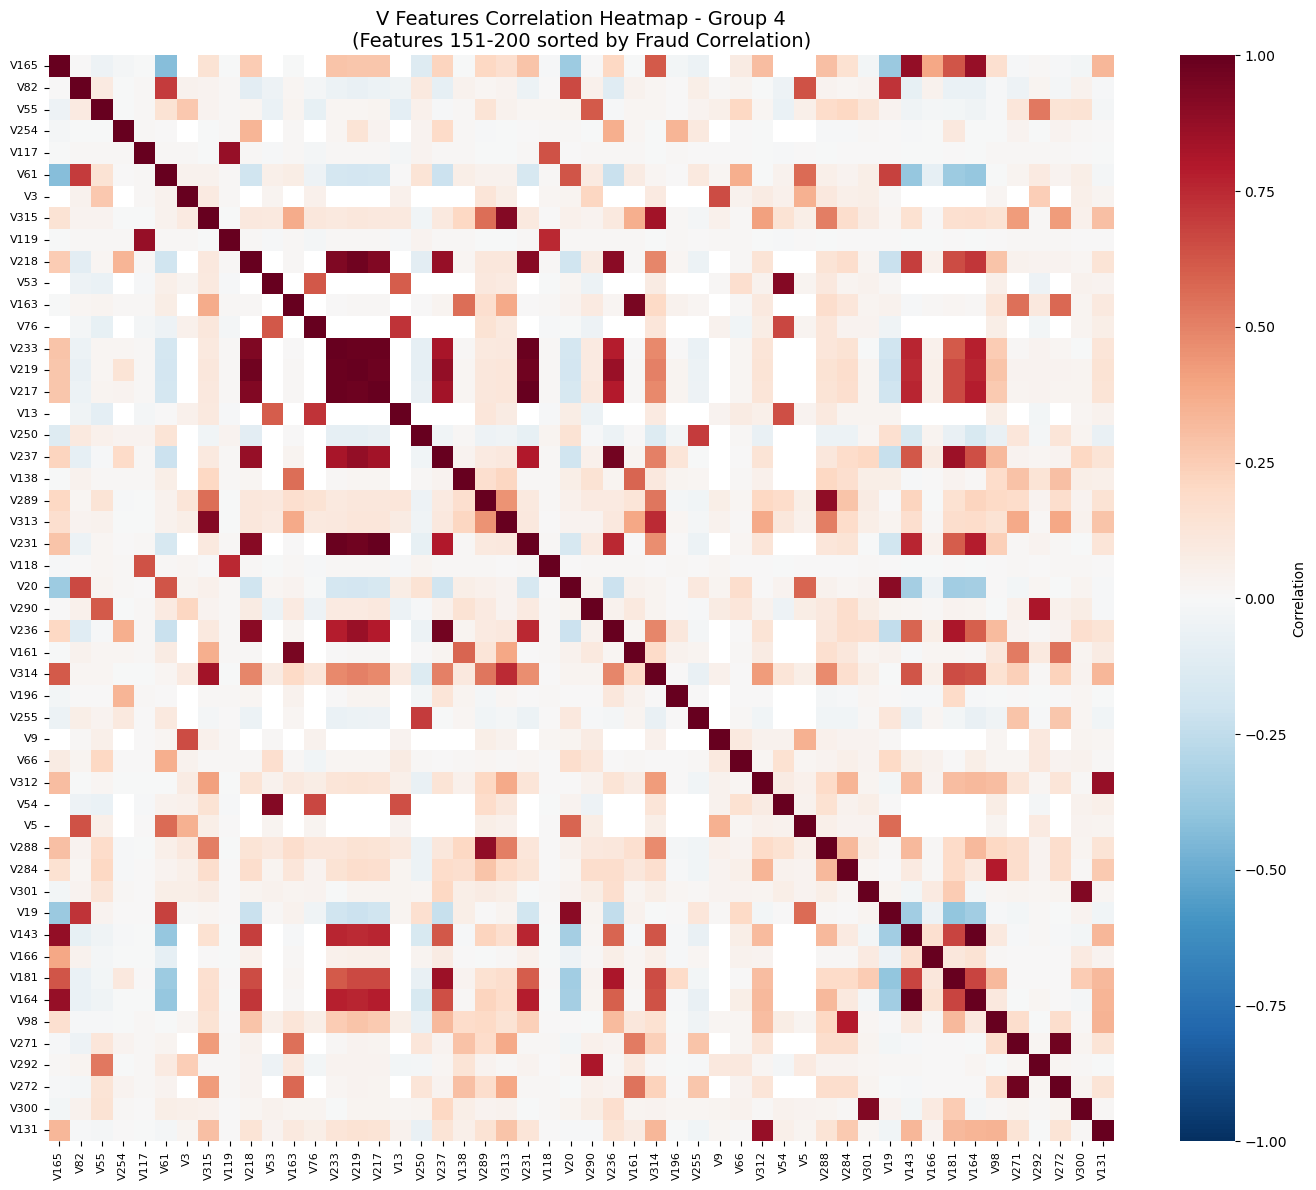


GROUP 4 - Top 5 Most Correlated Feature Pairs
  V143 <-> V164: 0.9966
  V217 <-> V231: 0.9960
  V233 <-> V231: 0.9915
  V233 <-> V217: 0.9897
  V233 <-> V219: 0.9884



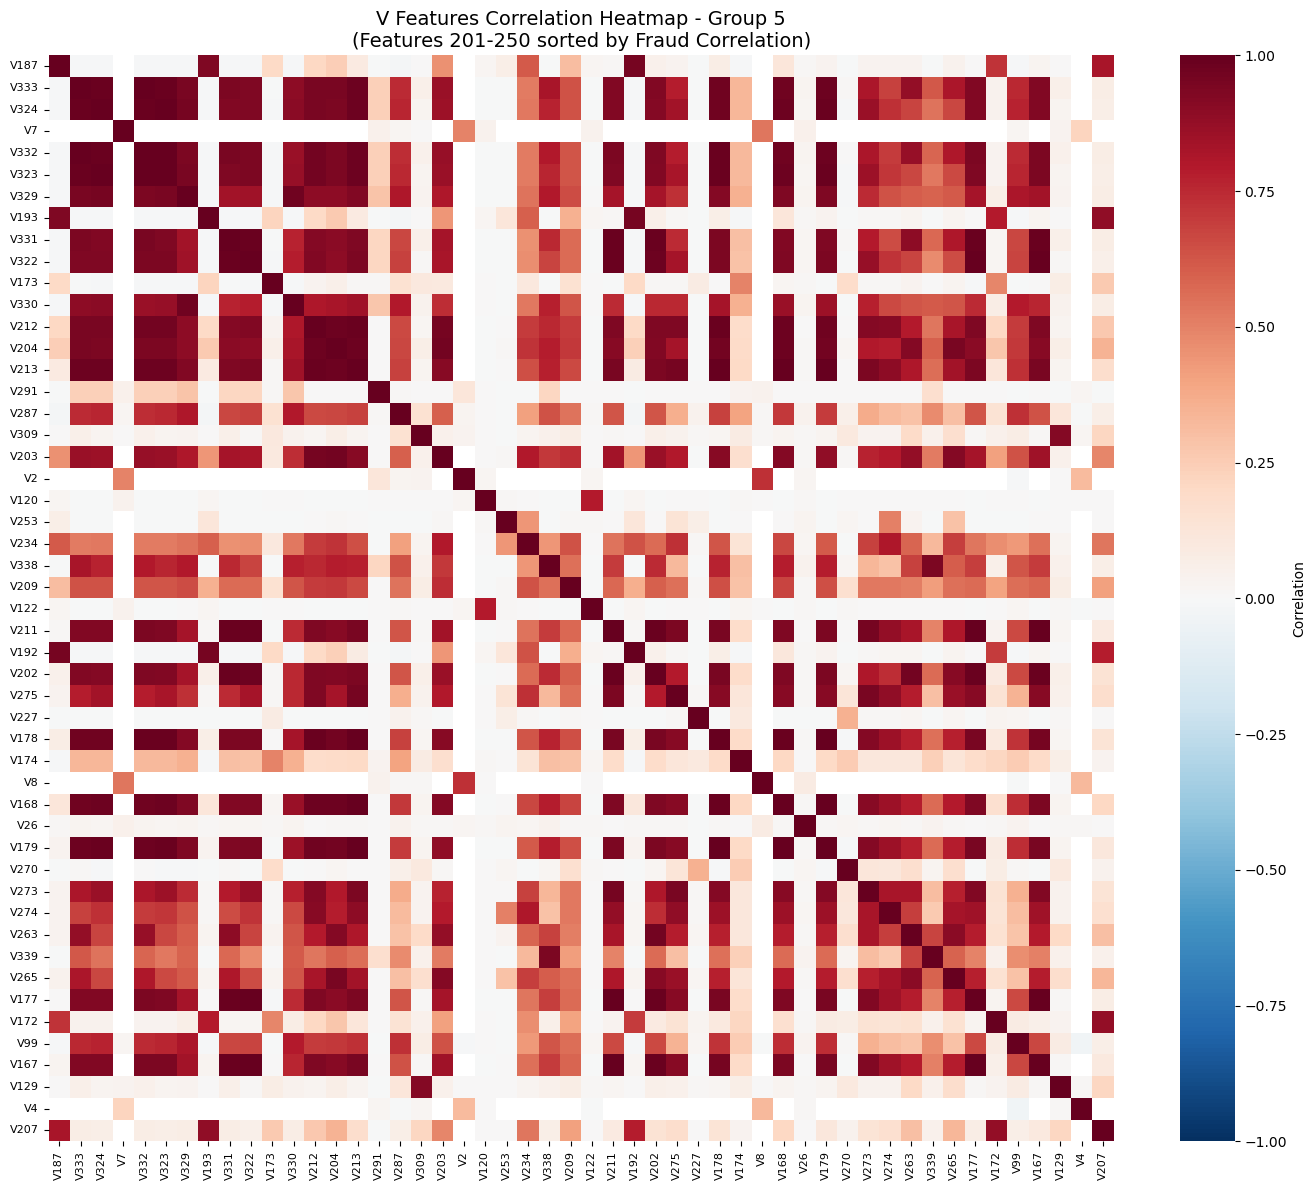


GROUP 5 - Top 5 Most Correlated Feature Pairs
  V177 <-> V167: 0.9994
  V211 <-> V177: 0.9981
  V211 <-> V167: 0.9978
  V213 <-> V179: 0.9960
  V213 <-> V168: 0.9958



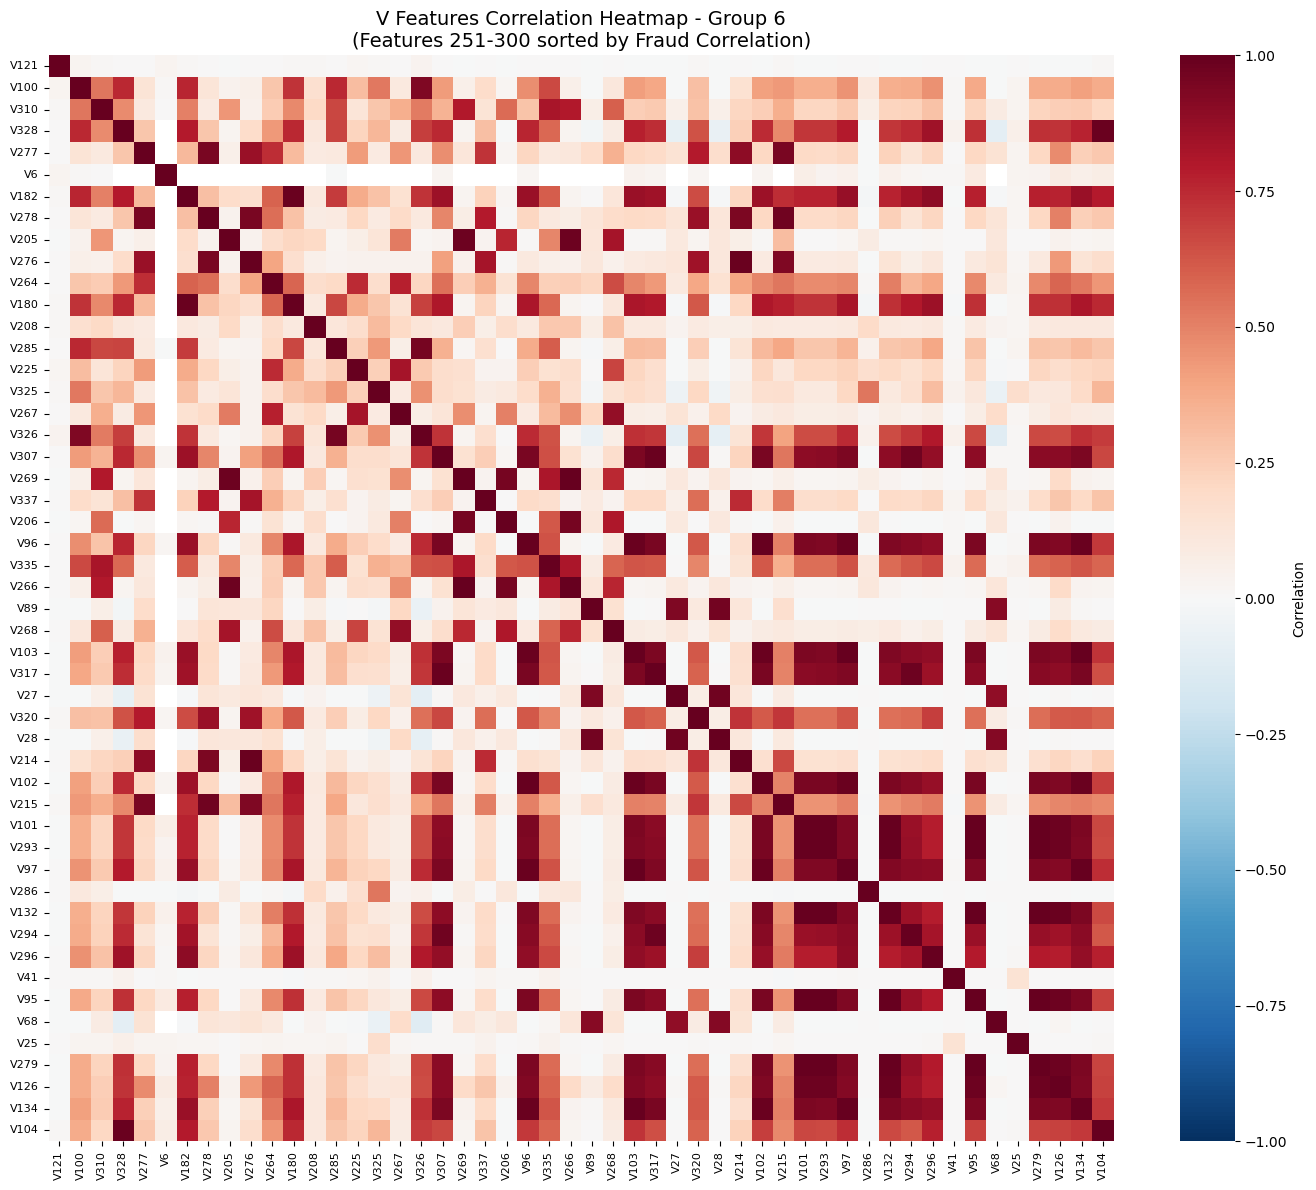


GROUP 6 - Top 5 Most Correlated Feature Pairs
  V101 <-> V95: 0.9996
  V293 <-> V279: 0.9996
  V101 <-> V293: 0.9989
  V103 <-> V97: 0.9988
  V95 <-> V279: 0.9987



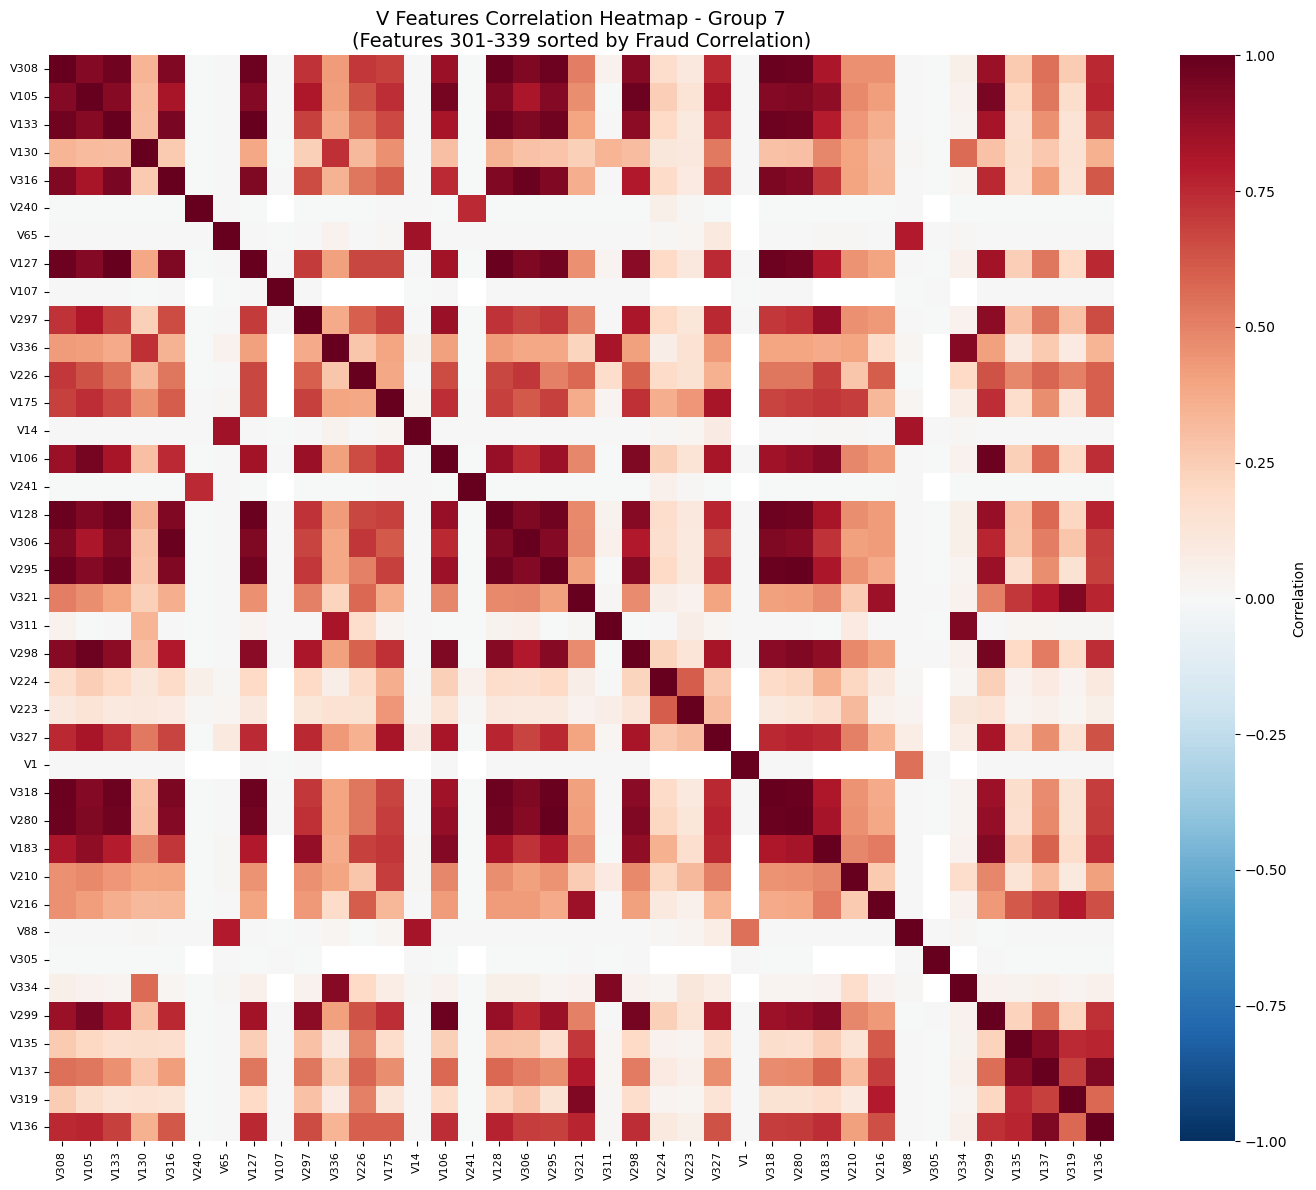


GROUP 7 - Top 5 Most Correlated Feature Pairs
  V295 <-> V280: 0.9986
  V133 <-> V127: 0.9923
  V295 <-> V318: 0.9919
  V308 <-> V318: 0.9907
  V318 <-> V280: 0.9906



In [ ]:
# V features correlation heatmap in groups of 50 (sorted by fraud correlation)
v_cols = [col for col in df.columns if col.startswith('V')]
v_target_corr = df[v_cols + ['isFraud']].corr()['isFraud'].drop('isFraud').abs().sort_values(ascending=False)

# Sort V features by fraud correlation
v_sorted = v_target_corr.index.tolist()

# Split into groups of 50
group_size = 50
n_groups = (len(v_sorted) + group_size - 1) // group_size

for i in range(n_groups):
    start_idx = i * group_size
    end_idx = min((i + 1) * group_size, len(v_sorted))
    group_cols = v_sorted[start_idx:end_idx]
    
    if len(group_cols) < 2:
        continue
    
    # Calculate correlation matrix for this group
    corr_matrix = df[group_cols].corr()
    
    # Plot heatmap
    fig, ax = plt.subplots(figsize=(14, 12))
    sns.heatmap(corr_matrix, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
                xticklabels=True, yticklabels=True, ax=ax,
                cbar_kws={'label': 'Correlation'})
    ax.set_title(f'V Features Correlation Heatmap - Group {i+1}\n(Features {start_idx+1}-{end_idx} sorted by Fraud Correlation)', 
                 fontsize=14)
    plt.xticks(rotation=90, fontsize=8)
    plt.yticks(fontsize=8)
    plt.tight_layout()
    plt.show()
    
    # Find top 5 most correlated pairs (excluding diagonal)
    corr_pairs = []
    for j in range(len(group_cols)):
        for k in range(j+1, len(group_cols)):
            corr_pairs.append({
                'Feature 1': group_cols[j],
                'Feature 2': group_cols[k],
                'Correlation': abs(corr_matrix.iloc[j, k])
            })
    
    top_corr = pd.DataFrame(corr_pairs).nlargest(5, 'Correlation')
    
    print(f"\n{'='*60}")
    print(f"GROUP {i+1} - Top 5 Most Correlated Feature Pairs")
    print(f"{'='*60}")
    for idx, row in top_corr.iterrows():
        print(f"  {row['Feature 1']} <-> {row['Feature 2']}: {row['Correlation']:.4f}")
    print()

## 8. Identity Features Analysis

Total ID features: 38
Numeric ID features: 23
Categorical ID features: 15


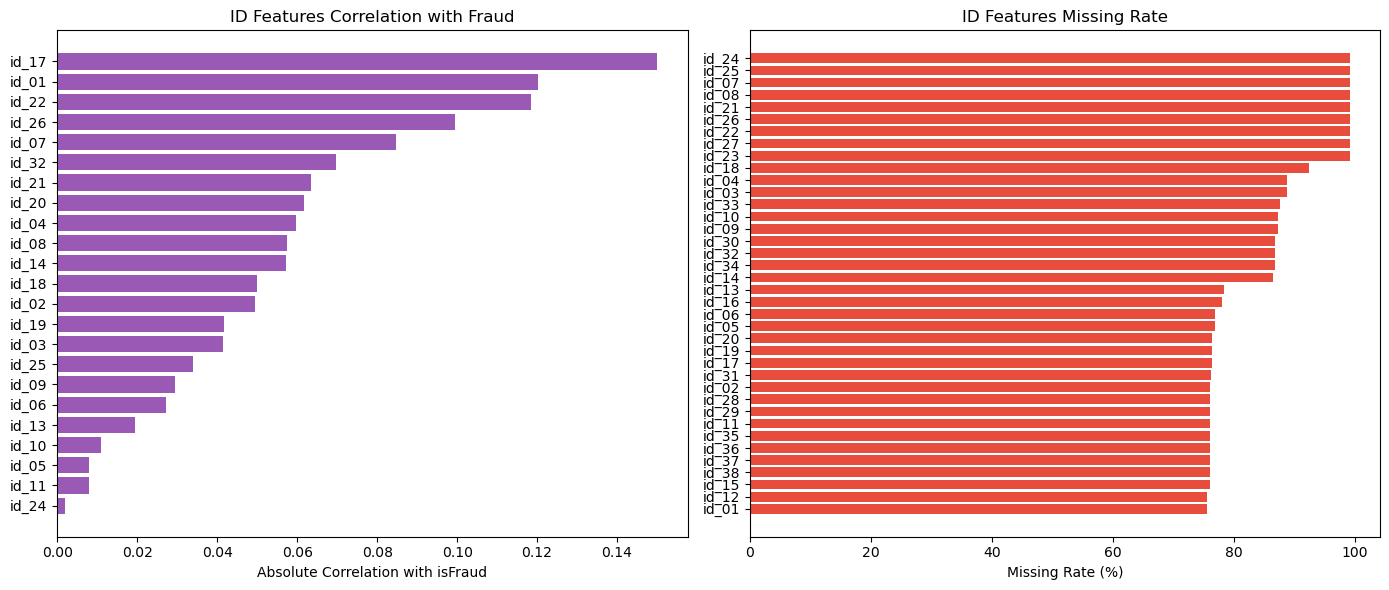


Device Type Analysis:
                 mean  count
DeviceType                  
desktop      6.521458  85165
mobile      10.166232  55645


In [ ]:
# Identity features (id_01 - id_38)
id_cols = [col for col in df.columns if col.startswith('id_')]
print(f"Total ID features: {len(id_cols)}")

# Check which ones are numeric vs categorical
id_numeric = [col for col in id_cols if df[col].dtype in ['int64', 'float64', 'Int8', 'Int16', 'Int32']]
id_categorical = [col for col in id_cols if col not in id_numeric]

print(f"Numeric ID features: {len(id_numeric)}")
print(f"Categorical ID features: {len(id_categorical)}")

# Correlation of numeric ID features with fraud
if id_numeric:
    id_corr = df[id_numeric + ['isFraud']].corr()['isFraud'].drop('isFraud').abs().sort_values(ascending=False)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # Correlation
    axes[0].barh(id_corr.index, id_corr.values, color='#9b59b6')
    axes[0].set_xlabel('Absolute Correlation with isFraud')
    axes[0].set_title('ID Features Correlation with Fraud')
    axes[0].invert_yaxis()
    
    # Missing rate
    id_missing = df[id_cols].isnull().mean().sort_values(ascending=False) * 100
    axes[1].barh(id_missing.index, id_missing.values, color='#e74c3c')
    axes[1].set_xlabel('Missing Rate (%)')
    axes[1].set_title('ID Features Missing Rate')
    axes[1].invert_yaxis()
    
    plt.tight_layout()
    plt.show()

# Device analysis
if 'DeviceType' in df.columns:
    print("\nDevice Type Analysis:")
    device_fraud = df.groupby('DeviceType')['isFraud'].agg(['mean', 'count'])
    device_fraud['mean'] = device_fraud['mean'] * 100
    print(device_fraud.to_string())

ID FEATURES - MISSING RATE & FRAUD CORRELATION ANALYSIS
Feature         Missing %   Fraud Corr       Recommendation
--------------------------------------------------------------------------------
id_24              99.20%       0.0019               🔴 DROP
id_25              99.13%       0.0340               🔴 DROP
id_08              99.13%       0.0575        🟡 IMPUTE/FLAG
id_07              99.13%       0.0848        🟡 IMPUTE/FLAG
id_21              99.13%       0.0635        🟡 IMPUTE/FLAG
id_26              99.13%       0.0996        🟡 IMPUTE/FLAG
id_22              99.12%       0.1184        🟡 IMPUTE/FLAG
id_23              99.12%    N/A (cat)               🔴 DROP
id_27              99.12%    N/A (cat)               🔴 DROP
id_18              92.36%       0.0500        🟡 IMPUTE/FLAG
id_03              88.77%       0.0415               🔴 DROP
id_04              88.77%       0.0597        🟡 IMPUTE/FLAG
id_33              87.59%    N/A (cat)               🔴 DROP
id_10              87.3

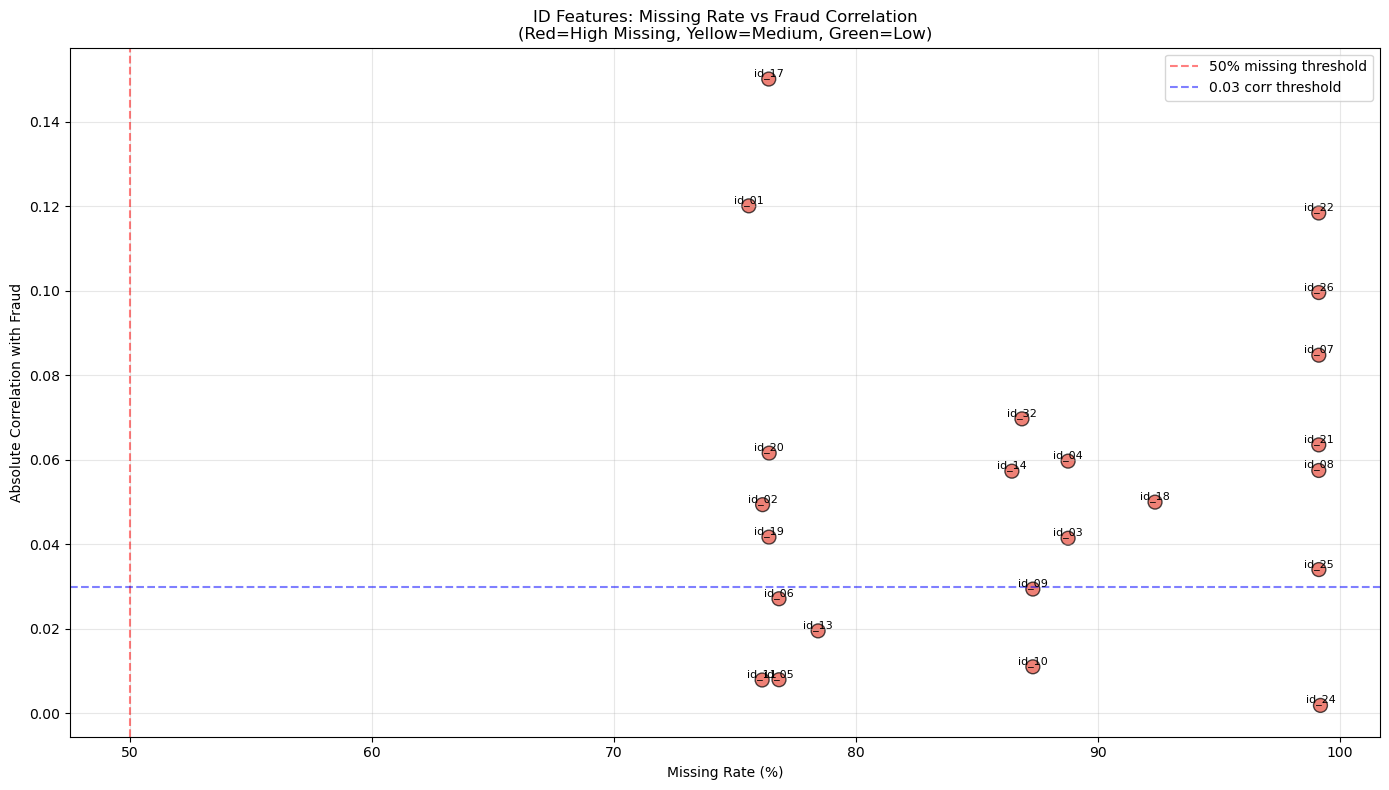

In [ ]:
# ID features - Missing rate vs Fraud correlation analysis
id_cols = [col for col in df.columns if col.startswith('id_')]

# Calculate missing rate and correlation for each ID feature
id_analysis = pd.DataFrame({
    'missing_rate': df[id_cols].isnull().mean() * 100,
})

# Correlation with fraud (only for numeric ID features)
id_numeric = [col for col in id_cols if df[col].dtype in ['int64', 'float64', 'Int8', 'Int16', 'Int32']]
id_corr_values = df[id_numeric + ['isFraud']].corr()['isFraud'].drop('isFraud').abs()

# Add correlation to analysis (NaN for categorical)
id_analysis['fraud_corr'] = id_analysis.index.map(lambda x: id_corr_values.get(x, np.nan))

# Sort by missing rate (descending) and correlation (ascending)
id_analysis_sorted = id_analysis.sort_values(['missing_rate', 'fraud_corr'], ascending=[False, True])

print("="*80)
print("ID FEATURES - MISSING RATE & FRAUD CORRELATION ANALYSIS")
print("="*80)
print(f"{'Feature':<12} {'Missing %':>12} {'Fraud Corr':>12} {'Recommendation':>20}")
print("-"*80)

for idx, row in id_analysis_sorted.iterrows():
    missing = row['missing_rate']
    corr = row['fraud_corr']
    
    # Recommendation based on both metrics
    if missing > 70 and (pd.isna(corr) or corr < 0.045):
        rec = "🔴 DROP"
    elif missing > 50 and (pd.isna(corr) or corr < 0.03):
        rec = "🟠 CONSIDER DROP"
    elif missing > 30:
        rec = "🟡 IMPUTE/FLAG"
    else:
        rec = "🟢 KEEP"
    
    corr_str = f"{corr:.4f}" if not pd.isna(corr) else "N/A (cat)"
    print(f"{idx:<12} {missing:>11.2f}% {corr_str:>12} {rec:>20}")

print("="*80)

# Summary statistics
high_missing_low_corr = id_analysis[(id_analysis['missing_rate'] > 50) & 
                                     ((id_analysis['fraud_corr'] < 0.03) | 
                                      (id_analysis['fraud_corr'].isna()))]
print(f"\n📊 SUMMARY:")
print(f"   - Total ID features: {len(id_cols)}")
print(f"   - High missing (>50%) & Low correlation (<0.03): {len(high_missing_low_corr)}")
print(f"   - Candidates for removal: {list(high_missing_low_corr.index)}")

# Visualization
fig, ax = plt.subplots(figsize=(14, 8))

# Scatter plot: Missing rate vs Correlation
scatter_data = id_analysis.dropna(subset=['fraud_corr'])
colors = ['#e74c3c' if m > 50 else '#f39c12' if m > 30 else '#2ecc71' 
          for m in scatter_data['missing_rate']]

ax.scatter(scatter_data['missing_rate'], scatter_data['fraud_corr'], 
           c=colors, s=100, alpha=0.7, edgecolors='black')

for idx, row in scatter_data.iterrows():
    ax.annotate(idx, (row['missing_rate'], row['fraud_corr']), 
                fontsize=8, ha='center', va='bottom')

ax.axvline(x=50, color='red', linestyle='--', alpha=0.5, label='50% missing threshold')
ax.axhline(y=0.03, color='blue', linestyle='--', alpha=0.5, label='0.03 corr threshold')
ax.set_xlabel('Missing Rate (%)')
ax.set_ylabel('Absolute Correlation with Fraud')
ax.set_title('ID Features: Missing Rate vs Fraud Correlation\n(Red=High Missing, Yellow=Medium, Green=Low)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# ID features - Correlation Analysis
id_cols = [col for col in df.columns if col.startswith('id_')]
id_numeric = [col for col in id_cols if df[col].dtype in ['int64', 'float64', 'Int8', 'Int16', 'Int32']]

print(f"Analyzing correlations among {len(id_numeric)} numeric ID features...")

# Calculate correlation matrix
id_corr_matrix = df[id_numeric].corr()

# Plot heatmap
fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(id_corr_matrix, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            xticklabels=True, yticklabels=True, ax=ax,
            cbar_kws={'label': 'Correlation'})
ax.set_title('ID Features Correlation Heatmap', fontsize=14)
plt.xticks(rotation=90, fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

# Find highly correlated ID feature pairs (>0.7 correlation)
corr_pairs = []
for i in range(len(id_numeric)):
    for j in range(i+1, len(id_numeric)):
        corr_val = abs(id_corr_matrix.iloc[i, j])
        if corr_val > 0.7:
            corr_pairs.append({
                'Feature 1': id_numeric[i],
                'Feature 2': id_numeric[j],
                'Correlation': corr_val
            })

if corr_pairs:
    corr_df = pd.DataFrame(corr_pairs).sort_values('Correlation', ascending=False)
    
    print("\n" + "="*80)
    print("HIGHLY CORRELATED ID FEATURE PAIRS (|correlation| > 0.7)")
    print("="*80)
    print(corr_df.to_string(index=False))
    print("="*80)
    
    # Plot top correlated pairs
    if len(corr_df) > 0:
        top_pairs = corr_df.head(10)
        
        fig, ax = plt.subplots(figsize=(12, 6))
        pair_labels = [f"{row['Feature 1']}\n↔\n{row['Feature 2']}" 
                       for _, row in top_pairs.iterrows()]
        colors = plt.cm.Reds(top_pairs['Correlation'] / top_pairs['Correlation'].max())
        
        bars = ax.barh(pair_labels, top_pairs['Correlation'], color=colors)
        ax.set_xlabel('Absolute Correlation')
        ax.set_title('Top 10 Most Correlated ID Feature Pairs')
        ax.invert_yaxis()
        
        for bar, corr in zip(bars, top_pairs['Correlation']):
            ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2, 
                   f'{corr:.3f}', va='center', fontweight='bold')
        
        plt.tight_layout()
        plt.show()
        
        print(f"\n💡 Recommendation: Consider removing one feature from highly correlated pairs")
        print(f"   to reduce multicollinearity and feature redundancy.")
else:
    print("\n✓ No highly correlated ID feature pairs found (threshold: 0.7)")

## 9. Feature Importance Summary & Recommendations

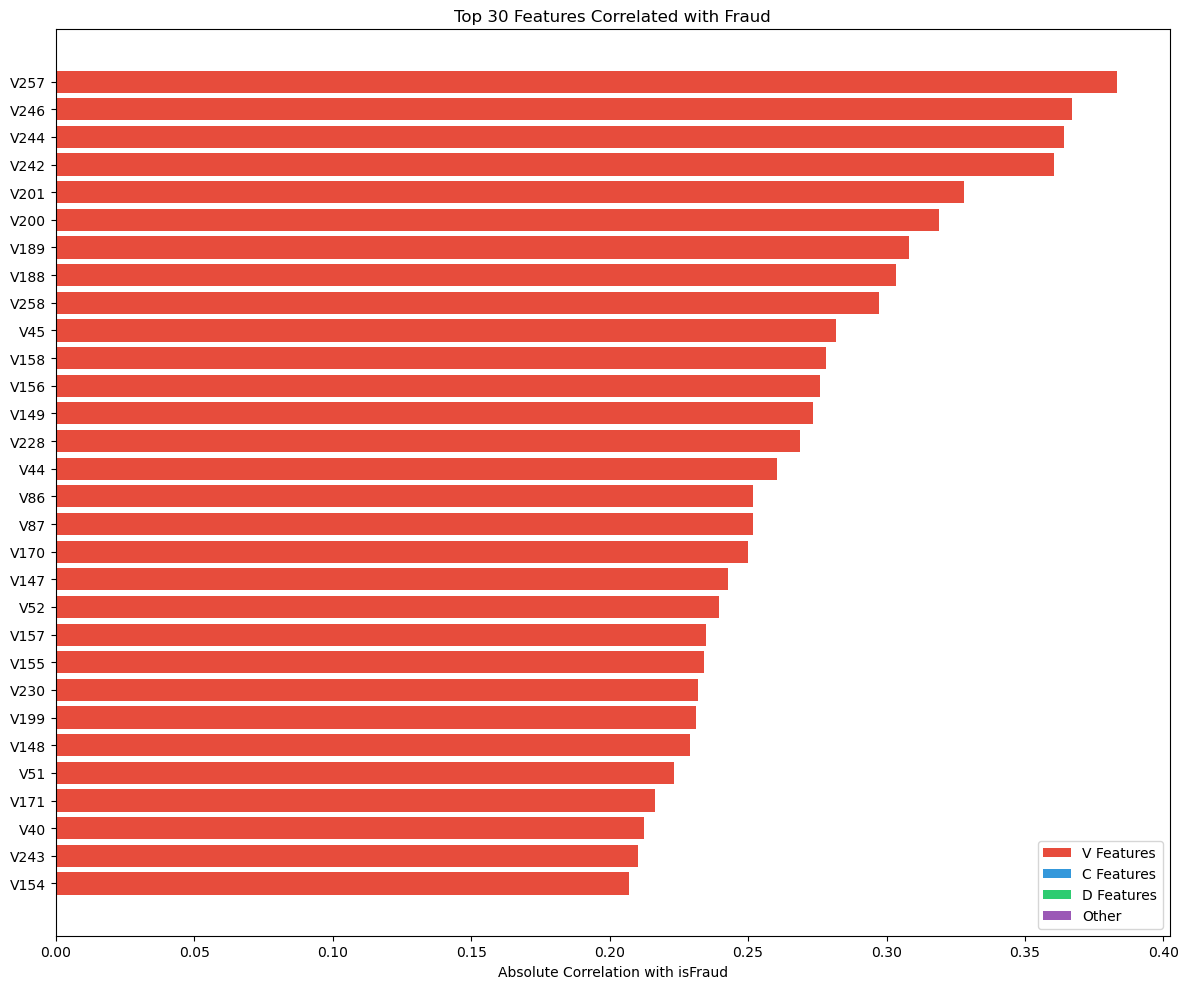

EDA SUMMARY & RECOMMENDATIONS

📊 DATASET OVERVIEW:
   - Total Features: 433
   - Fraud Rate: 3.50% (Highly Imbalanced)
   
🔑 KEY FINDINGS:
   1. V features (Vesta) are most predictive - 30 in top 30
   2. C features (Count) show strong fraud signals
   3. Time features reveal fraud patterns by hour
   4. High missing rate in identity features (~40%)
   
⚡ RECOMMENDATIONS FOR MODELING:
   1. Use class_weight='balanced' or SMOTE for imbalance
   2. Focus on V features for feature selection
   3. Create time-based features (hour, day_of_week)
   4. Handle missing values carefully (especially identity)
   5. Use TimeSeriesSplit for validation (time-based data)
   
🎯 POTENTIAL NEW FEATURES:
   - Transaction amount bins
   - Hour of transaction
   - Email domain matching (P vs R)
   - Card info aggregations



In [ ]:
# Overall correlation analysis - Top features
numeric_df = df.select_dtypes(include=[np.number])
all_corr = numeric_df.corr()['isFraud'].drop('isFraud').abs().sort_values(ascending=False)

# Top 30 features
top_30 = all_corr.head(30)

plt.figure(figsize=(12, 10))
colors = ['#e74c3c' if 'V' in idx else '#3498db' if 'C' in idx else '#2ecc71' if 'D' in idx else '#9b59b6' for idx in top_30.index]
plt.barh(top_30.index, top_30.values, color=colors)
plt.xlabel('Absolute Correlation with isFraud')
plt.title('Top 30 Features Correlated with Fraud')
plt.gca().invert_yaxis()

# Add legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#e74c3c', label='V Features'),
                   Patch(facecolor='#3498db', label='C Features'),
                   Patch(facecolor='#2ecc71', label='D Features'),
                   Patch(facecolor='#9b59b6', label='Other')]
plt.legend(handles=legend_elements, loc='lower right')
plt.tight_layout()
plt.show()

# Summary
print("="*80)
print("EDA SUMMARY & RECOMMENDATIONS")
print("="*80)
print(f"""
📊 DATASET OVERVIEW:
   - Total Features: {len(df.columns)}
   - Fraud Rate: {df['isFraud'].mean()*100:.2f}% (Highly Imbalanced)
   
🔑 KEY FINDINGS:
   1. V features (Vesta) are most predictive - {len([c for c in top_30.index if 'V' in c])} in top 30
   2. C features (Count) show strong fraud signals
   3. Time features reveal fraud patterns by hour
   4. High missing rate in identity features (~40%)
   
⚡ RECOMMENDATIONS FOR MODELING:
   1. Use class_weight='balanced' or SMOTE for imbalance
   2. Focus on V features for feature selection
   3. Create time-based features (hour, day_of_week)
   4. Handle missing values carefully (especially identity)
   5. Use TimeSeriesSplit for validation (time-based data)
   
🎯 POTENTIAL NEW FEATURES:
   - Transaction amount bins
   - Hour of transaction
   - Email domain matching (P vs R)
   - Card info aggregations
""")
print("="*80)

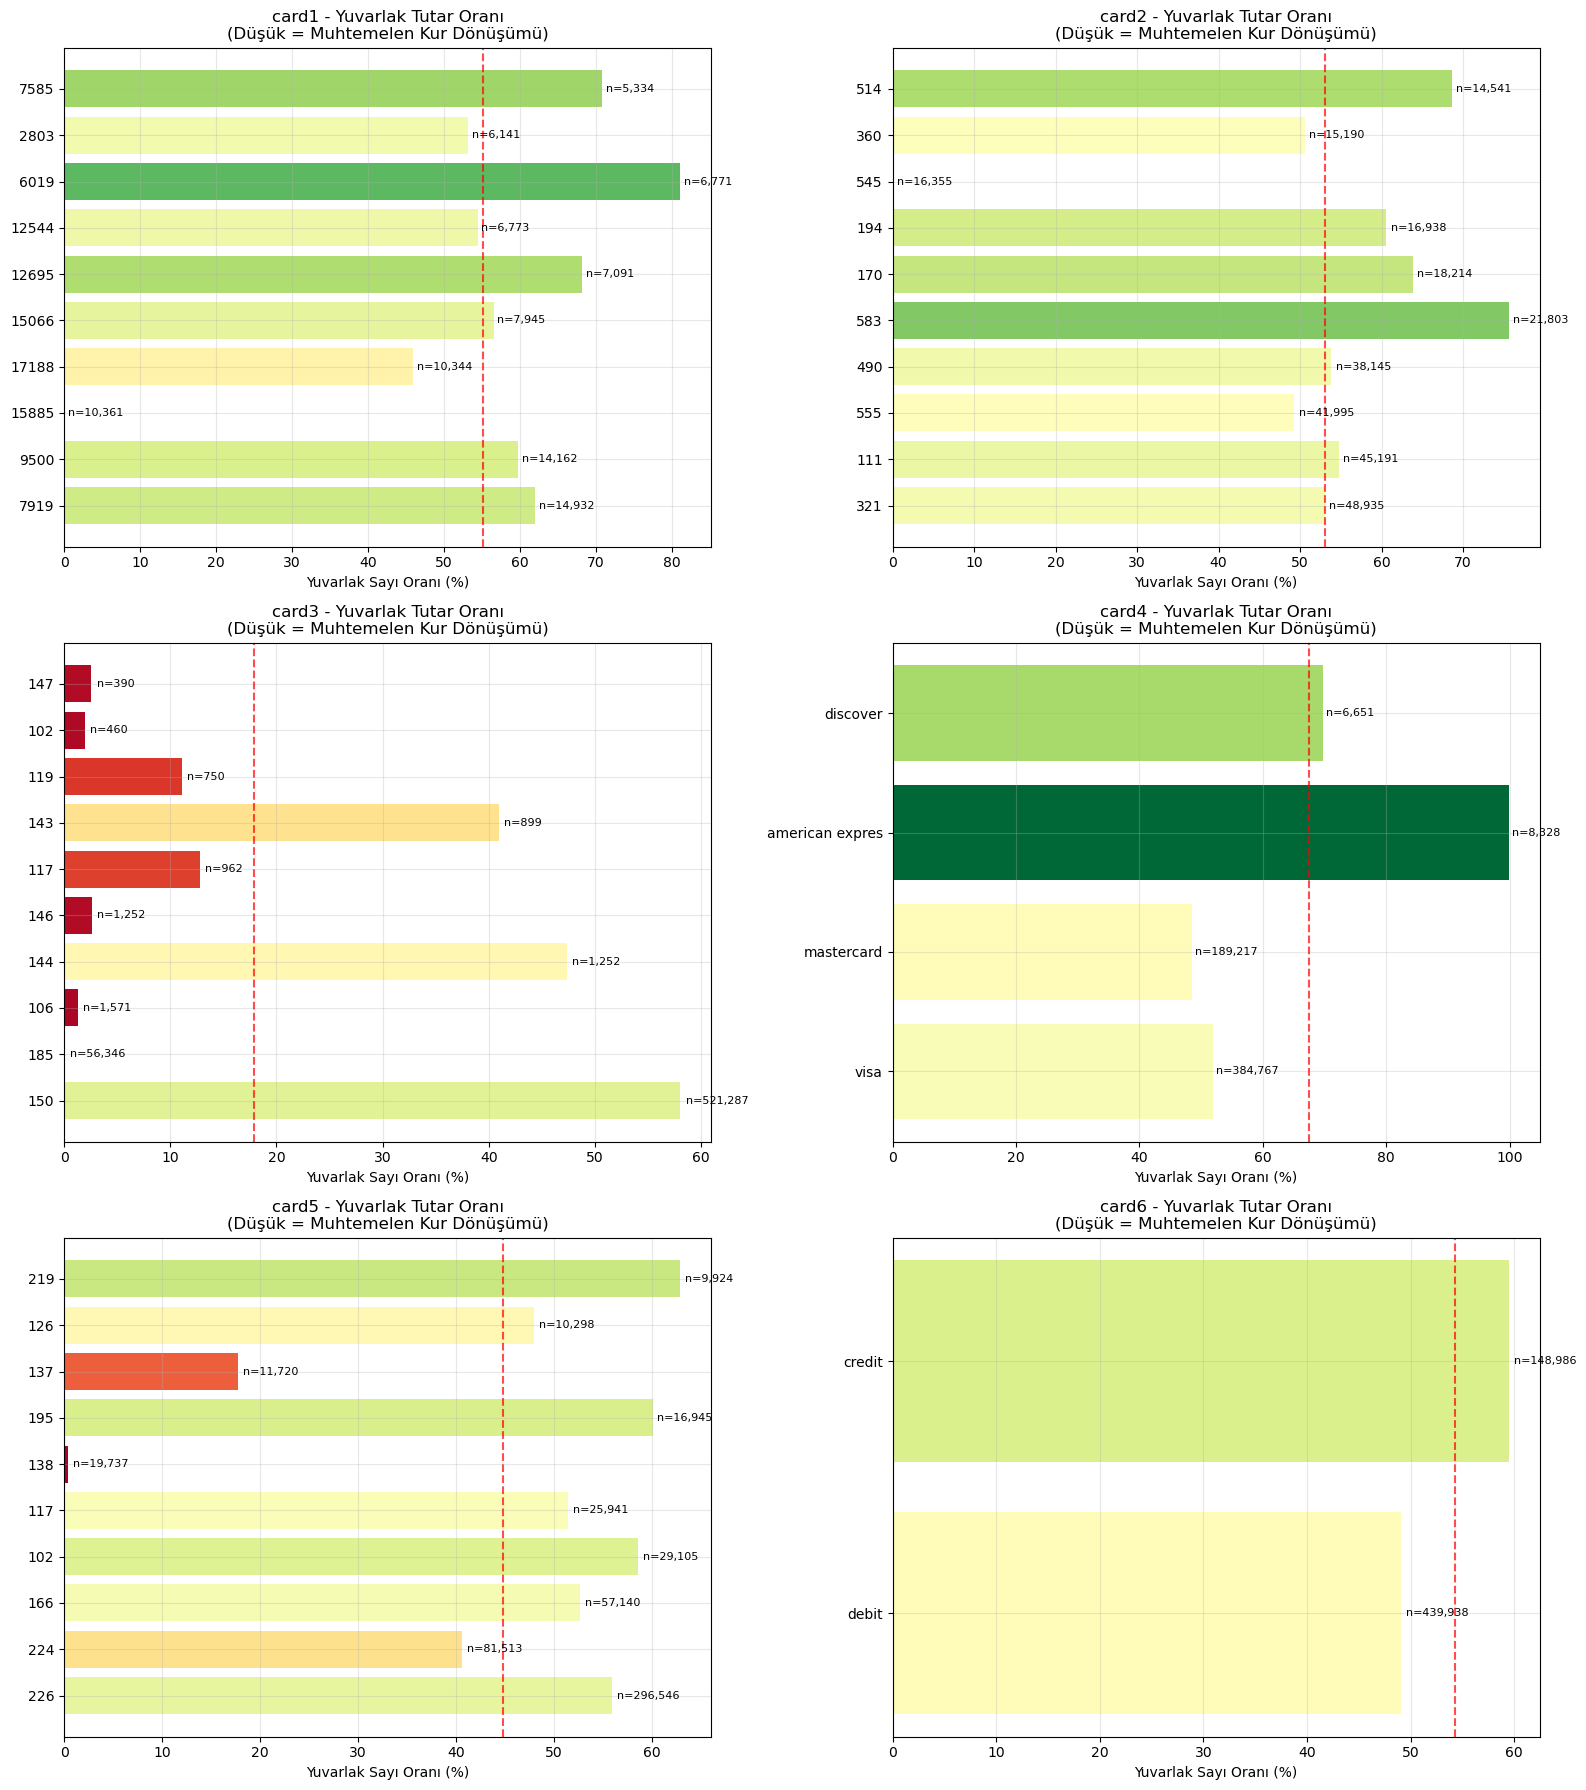

CARD ÖZELLİKLERİ - ONDALIK KISIM ANALİZİ (ÜLKE/BÖLGE TESPİTİ)

📊 CARD1 ANALİZİ
   Unique değer sayısı: 13,553
   Missing: 0.0%

   Değer                Count   Round%  MeanDec   StdDec   Fraud%       AvgAmt
   ---------------------------------------------------------------------------
   7919                14,932    62.0%    0.330    0.436    0.75% $    101.21 🇺🇸
   9500                14,162    59.7%    0.356    0.446    3.73% $    115.70 🇺🇸
   15885               10,361     0.1%    0.496    0.289    4.29% $     39.46 🌍
   17188               10,344    45.9%    0.485    0.462    2.69% $    129.63 ❓
   15066                7,945    56.5%    0.348    0.430    3.94% $    209.86 🇺🇸
   12695                7,091    68.2%    0.270    0.411    2.83% $    141.14 🇺🇸
   12544                6,773    54.4%    0.407    0.458    2.16% $    108.96 🇺🇸
   6019                 6,771    81.1%    0.141    0.317    4.34% $    225.44 🇺🇸
   2803                 6,141    53.1%    0.418    0.459    1.19% $ 

In [17]:
# =============================================================================
# CARD FEATURES - ÜLKE/BÖLGE TESPİTİ (TransactionAmt Ondalık Analizi)
# =============================================================================
# Hipotez: USD kullanmayan ülkeler kur dönüşümü yaptığında ondalık kısımlar farklı olur

fig, axes = plt.subplots(3, 2, figsize=(16, 18))

card_cols = ['card1', 'card2', 'card3', 'card4', 'card5', 'card6']

# Ondalık kısım hesapla
df['amt_decimal'] = df['TransactionAmt'] % 1
df['is_round'] = (df['amt_decimal'] == 0).astype(int)
df['cents'] = (df['amt_decimal'] * 100).round().astype(int)

# Her card değişkeni için analiz
for idx, col in enumerate(card_cols):
    ax = axes[idx // 2, idx % 2]
    
    if col not in df.columns:
        ax.text(0.5, 0.5, f'{col} not found', ha='center', va='center')
        continue
    
    # En popüler değerleri al
    top_values = df[col].value_counts().head(10).index.tolist()
    
    # Her değer için ondalık analizi
    decimal_stats = []
    for val in top_values:
        subset = df[df[col] == val]
        if len(subset) > 100:
            decimal_stats.append({
                'value': str(val)[:15],
                'count': len(subset),
                'round_pct': subset['is_round'].mean() * 100,
                'mean_decimal': subset['amt_decimal'].mean(),
                'std_decimal': subset['amt_decimal'].std(),
                'fraud_rate': subset['isFraud'].mean() * 100,
                'mean_amt': subset['TransactionAmt'].mean()
            })
    
    if decimal_stats:
        stats_df = pd.DataFrame(decimal_stats)
        
        # Yuvarlak sayı yüzdesini göster
        colors = plt.cm.RdYlGn(stats_df['round_pct'] / 100)
        bars = ax.barh(stats_df['value'], stats_df['round_pct'], color=colors)
        ax.set_xlabel('Yuvarlak Sayı Oranı (%)')
        ax.set_title(f'{col} - Yuvarlak Tutar Oranı\n(Düşük = Muhtemelen Kur Dönüşümü)')
        ax.axvline(x=stats_df['round_pct'].mean(), color='red', linestyle='--', alpha=0.7)
        
        for bar, row in zip(bars, stats_df.itertuples()):
            ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2, 
                   f'n={row.count:,}', va='center', fontsize=8)
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Detaylı Card Analizi
print("="*100)
print("CARD ÖZELLİKLERİ - ONDALIK KISIM ANALİZİ (ÜLKE/BÖLGE TESPİTİ)")
print("="*100)

for col in card_cols:
    if col not in df.columns:
        continue
        
    print(f"\n{'='*50}")
    print(f"📊 {col.upper()} ANALİZİ")
    print(f"{'='*50}")
    print(f"   Unique değer sayısı: {df[col].nunique():,}")
    print(f"   Missing: {df[col].isna().mean()*100:.1f}%")
    
    # Top 15 değer için detaylı analiz
    top_values = df[col].value_counts().head(15).index.tolist()
    
    print(f"\n   {'Değer':<15} {'Count':>10} {'Round%':>8} {'MeanDec':>8} {'StdDec':>8} {'Fraud%':>8} {'AvgAmt':>12}")
    print(f"   {'-'*75}")
    
    for val in top_values:
        subset = df[df[col] == val]
        if len(subset) > 50:
            round_pct = subset['is_round'].mean() * 100
            mean_dec = subset['amt_decimal'].mean()
            std_dec = subset['amt_decimal'].std()
            fraud_rate = subset['isFraud'].mean() * 100
            avg_amt = subset['TransactionAmt'].mean()
            
            # Ülke işareti (düşük round % = muhtemelen kur dönüşümü)
            flag = "🌍" if round_pct < 30 else "🇺🇸" if round_pct > 50 else "❓"
            
            print(f"   {str(val):<15} {len(subset):>10,} {round_pct:>7.1f}% {mean_dec:>8.3f} {std_dec:>8.3f} {fraud_rate:>7.2f}% ${avg_amt:>10.2f} {flag}")

# Temizlik
df.drop(['amt_decimal', 'is_round', 'cents'], axis=1, inplace=True)

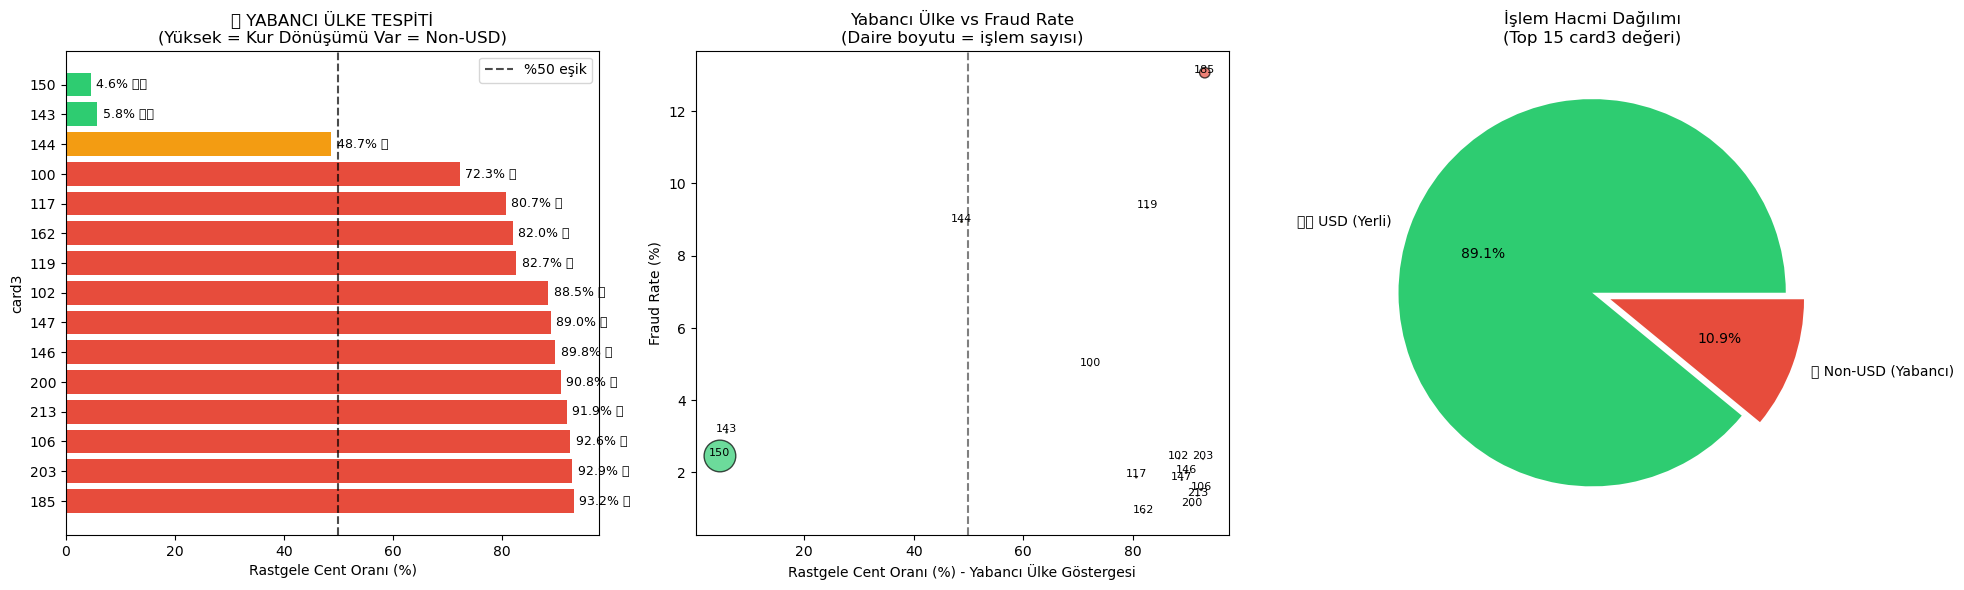

🌍 YABANCI ÜLKE TESPİTİ - CARD3 ANALİZİ
Mantık: USD pattern'leri (.00, .25, .49, .50, .75, .90, .95, .99) DIŞINDA kalan cent oranı
        Yüksek oran = Kur dönüşümü var = Yabancı para birimi kullanıyor

   card3        Count    Random%     Fraud%       AvgAmt               Tespit
--------------------------------------------------------------------------------
     185       56,346      93.2%     13.07% $     42.27  🌍 YABANCI (Non-USD)
     203          253      92.9%      2.37% $     45.49  🌍 YABANCI (Non-USD)
     106        1,571      92.6%      1.53% $     46.49  🌍 YABANCI (Non-USD)
     213          221      91.9%      1.36% $     48.98  🌍 YABANCI (Non-USD)
     200          184      90.8%      1.09% $     58.35  🌍 YABANCI (Non-USD)
     146        1,252      89.8%      2.00% $     45.53  🌍 YABANCI (Non-USD)
     147          390      89.0%      1.79% $     48.91  🌍 YABANCI (Non-USD)
     102          460      88.5%      2.39% $     43.48  🌍 YABANCI (Non-USD)
     119          750 

In [20]:
# =============================================================================
# CARD3 - YABANCI ÜLKE TESPİTİ (USD Pattern'leri DIŞINDA kalanların yoğunluğu)
# =============================================================================
# Mantık: USD işlemleri belirli cent değerlerinde yoğunlaşır (.00, .50, .99, .95, .49, .90, .25, .75)
#         Kur dönüşümü yapan ülkelerde cent değerleri RASTGELE dağılır

# Ondalık hesapla
df['amt_decimal'] = df['TransactionAmt'] % 1
df['cents'] = (df['amt_decimal'] * 100).round().astype(int)

# USD'nin tipik cent değerleri (psikolojik fiyatlama + yuvarlak)
usd_typical_cents = [0, 25, 49, 50, 75, 90, 95, 99]

# "Rastgele" cent değerleri = USD pattern'leri dışındakiler
df['is_random_cent'] = ~df['cents'].isin(usd_typical_cents)

# card3 analizi
card3_values = df['card3'].value_counts().head(15).index.tolist()

# Her card3 için rastgele cent oranı
random_cent_analysis = []
for card_val in card3_values:
    subset = df[df['card3'] == card_val]
    random_pct = subset['is_random_cent'].mean() * 100
    fraud_rate = subset['isFraud'].mean() * 100
    avg_amt = subset['TransactionAmt'].mean()
    
    random_cent_analysis.append({
        'card3': card_val,
        'count': len(subset),
        'random_cent_pct': random_pct,
        'fraud_rate': fraud_rate,
        'avg_amt': avg_amt
    })

analysis_df = pd.DataFrame(random_cent_analysis).sort_values('random_cent_pct', ascending=False)

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 1. Random Cent Oranı (Yabancı Ülke Göstergesi)
ax1 = axes[0]
colors = ['#e74c3c' if x > 60 else '#f39c12' if x > 40 else '#2ecc71' for x in analysis_df['random_cent_pct']]
bars = ax1.barh(analysis_df['card3'].astype(str), analysis_df['random_cent_pct'], color=colors)
ax1.axvline(x=50, color='black', linestyle='--', alpha=0.7, label='%50 eşik')
ax1.set_xlabel('Rastgele Cent Oranı (%)')
ax1.set_ylabel('card3')
ax1.set_title('🌍 YABANCI ÜLKE TESPİTİ\n(Yüksek = Kur Dönüşümü Var = Non-USD)')
ax1.legend()

for bar, row in zip(bars, analysis_df.itertuples()):
    label = "🌍" if row.random_cent_pct > 60 else "❓" if row.random_cent_pct > 40 else "🇺🇸"
    ax1.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2, 
             f'{row.random_cent_pct:.1f}% {label}', va='center', fontsize=9)

# 2. Fraud Rate vs Random Cent
ax2 = axes[1]
scatter_colors = ['#e74c3c' if x > 60 else '#f39c12' if x > 40 else '#2ecc71' for x in analysis_df['random_cent_pct']]
ax2.scatter(analysis_df['random_cent_pct'], analysis_df['fraud_rate'], 
            s=analysis_df['count']/1000, c=scatter_colors, alpha=0.7, edgecolors='black')
ax2.set_xlabel('Rastgele Cent Oranı (%) - Yabancı Ülke Göstergesi')
ax2.set_ylabel('Fraud Rate (%)')
ax2.set_title('Yabancı Ülke vs Fraud Rate\n(Daire boyutu = işlem sayısı)')
ax2.axvline(x=50, color='black', linestyle='--', alpha=0.5)

for _, row in analysis_df.iterrows():
    ax2.annotate(str(int(row['card3'])), (row['random_cent_pct'], row['fraud_rate']), 
                fontsize=8, ha='center')

# 3. İşlem Hacmi Dağılımı
ax3 = axes[2]
foreign_mask = analysis_df['random_cent_pct'] > 25
domestic = analysis_df[~foreign_mask]['count'].sum()
foreign = analysis_df[foreign_mask]['count'].sum()

ax3.pie([domestic, foreign], labels=['🇺🇸 USD (Yerli)', '🌍 Non-USD (Yabancı)'], 
        autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'], explode=[0, 0.1])
ax3.set_title(f'İşlem Hacmi Dağılımı\n(Top 15 card3 değeri)')

plt.tight_layout()
plt.show()

# Detaylı Tablo
print("="*100)
print("🌍 YABANCI ÜLKE TESPİTİ - CARD3 ANALİZİ")
print("="*100)
print("Mantık: USD pattern'leri (.00, .25, .49, .50, .75, .90, .95, .99) DIŞINDA kalan cent oranı")
print("        Yüksek oran = Kur dönüşümü var = Yabancı para birimi kullanıyor")
print("="*100)

print(f"\n{'card3':>8} {'Count':>12} {'Random%':>10} {'Fraud%':>10} {'AvgAmt':>12} {'Tespit':>20}")
print("-"*80)

for _, row in analysis_df.iterrows():
    if row['random_cent_pct'] > 60:
        tespit = "🌍 YABANCI (Non-USD)"
    elif row['random_cent_pct'] > 40:
        tespit = "❓ KARISIK"
    else:
        tespit = "🇺🇸 YERLİ (USD)"
    
    print(f"{int(row['card3']):>8} {int(row['count']):>12,} {row['random_cent_pct']:>9.1f}% {row['fraud_rate']:>9.2f}% ${row['avg_amt']:>10.2f} {tespit:>20}")

# Özet
print("\n" + "="*100)
print("📊 ÖZET")
print("="*100)

foreign_cards = analysis_df[analysis_df['random_cent_pct'] > 25]['card3'].tolist()
domestic_cards = analysis_df[analysis_df['random_cent_pct'] <= 25]['card3'].tolist()

print(f"\n🌍 YABANCI (Non-USD) card3 değerleri (random cent > %25):")
print(f"   {[int(x) for x in foreign_cards]}")

print(f"\n🇺🇸 YERLİ (USD) card3 değerleri (random cent <= %25):")
print(f"   {[int(x) for x in domestic_cards]}")

# Fraud karşılaştırması
foreign_fraud = df[df['card3'].isin(foreign_cards)]['isFraud'].mean() * 100
domestic_fraud = df[df['card3'].isin(domestic_cards)]['isFraud'].mean() * 100

print(f"\n⚠️ FRAUD RATE KARŞILAŞTIRMASI:")
print(f"   🌍 Yabancı (Non-USD) Fraud Rate: {foreign_fraud:.2f}%")
print(f"   🇺🇸 Yerli (USD) Fraud Rate: {domestic_fraud:.2f}%")
print(f"   Fark: {abs(foreign_fraud - domestic_fraud):.2f}%")

# Temizlik
df.drop(['amt_decimal', 'cents', 'is_random_cent'], axis=1, inplace=True)
print("="*100)